# DATUBASE-PH | Notebook 05: TFT Predictive Modeling Framework

**Research**: *Forecasting Political Dynasty Saturation in Philippine Provinces Using a Temporal Fusion Transformer*  
**Coverage**: §3.4 — Predictive Modeling Framework  

This notebook implements the full modeling pipeline:
- `§3.4.3` — Dataset partitioning and sequence configuration
- `§3.4.2` — TFT architecture configuration
- `§3.4.4` — Hyperparameter tuning via Optuna / saved Optuna trial loading
- `§3.4.5` — Baseline model benchmarking
- `§3.4.6` — Held-out ground-truth alignment and evaluation on 2019–2022
- `§3.4.7` — Final 2028 and 2031 forecast generation
- `§3.4.8` — Interpretability outputs and dashboard-ready exports

> **Important workflow correction:**  
> The notebook first trains a **held-out evaluation TFT** on 2000–2015 and validates on 2016–2018. This model is used only to compare predicted vs. actual 2019–2022 values.  
> After test evaluation is finished, the notebook trains a **separate final TFT** on the complete 2000–2022 panel for the 2028 and 2031 forecast outputs.


---
## 0 · Environment Setup

In [1]:
import os, random, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import optuna
from optuna.samplers import TPESampler

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility (§3.4.4) ────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
pl.seed_everything(SEED, workers=True)

# ── Paths ────────────────────────────────────────────────────────────────────
# Robust root detection: works whether the notebook is run from project root
# or from the notebooks/ directory.
CWD = Path().resolve()
ROOT = CWD if (CWD / 'data' / 'final').exists() else CWD.parent

DATA_DIR    = ROOT / 'data' / 'final'
OUT_DIR     = ROOT / 'outputs'
MODEL_DIR   = OUT_DIR / 'models'
RESULTS_DIR = OUT_DIR / 'results'
FIGURES_DIR = OUT_DIR / 'figures'

for d in [OUT_DIR, MODEL_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Project root: {ROOT}')
print(f'Device: {DEVICE} | Seed: {SEED}')


Seed set to 42


Project root: /Users/renzo/Projects/Datubase-ph
Device: cpu | Seed: 42


---
## 1 · Data Loading and Validation

In [2]:
df = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')

REQUIRED_COLS = [
    'prov_name', 'year', 'dynasty_share', 'gov_is_dynasty',
    'vice_gov_is_dynasty', 'ira_funding_million_php',
    'time_idx', 'poverty_incidence',
]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
assert not missing, f'Missing columns: {missing}'

# Coerce types
df['prov_name']           = df['prov_name'].astype(str).str.strip()
df['year']                = df['year'].astype(int)
df['time_idx']            = df['time_idx'].astype(int)
df['gov_is_dynasty']      = df['gov_is_dynasty'].astype(str)
df['vice_gov_is_dynasty'] = df['vice_gov_is_dynasty'].astype(str)

PROVINCES   = sorted(df['prov_name'].unique())
N_PROVINCES = len(PROVINCES)
YEARS       = sorted(df['year'].unique())

print(f'Provinces  : {N_PROVINCES}')
print(f'Year range : {YEARS[0]}–{YEARS[-1]}')
print(f'Total rows : {len(df):,}')
print(f'NaN count  : {df[REQUIRED_COLS].isna().sum().sum()}')
df.head()

Provinces  : 81
Year range : 2000–2022
Total rows : 1,863
NaN count  : 0


,prov_name,year,dynasty_share,gov_is_dynasty,vice_gov_is_dynasty,ira_funding_million_php,time_idx,poverty_incidence
0,Abra,2000,27.402136,0,1,199.7,0,61.700000
1,Abra,2001,32.384342,1,0,225.1,1,57.866667
2,Abra,2002,32.384342,1,0,259.0,2,54.033333
3,Abra,2003,32.384342,1,0,271.2,3,50.200000
4,Abra,2004,28.782288,1,0,271.2,4,53.700000


---
## 2 · Dataset Partitioning `§3.4.3`

| Split | Years | Motivation |
|-------|-------|------------|
| **Train** | 2000–2015 | 16 time steps, 1,296 obs |
| **Validation** | 2016–2018 | 3 steps, 243 obs — full triennial cycle boundary |
| **Test** | 2019–2022 | 4 steps, 324 obs — the analytical "third wave" |
| **Forecast** | 2023–2031 | Out-of-sample inference targets |

In [3]:
# Filter to historical window only (2000–2022)
df_hist = df[df['year'] <= 2022].copy().reset_index(drop=True)

TRAIN_END_IDX = int(df_hist.loc[df_hist['year'] == 2015, 'time_idx'].iloc[0])
VAL_END_IDX   = int(df_hist.loc[df_hist['year'] == 2018, 'time_idx'].iloc[0])
TEST_END_IDX  = int(df_hist.loc[df_hist['year'] == 2022, 'time_idx'].iloc[0])

# Sequence configuration
ENCODER_LENGTH    = 9   # 3 triennial cycles
PRED_LENGTH_VAL   = VAL_END_IDX - TRAIN_END_IDX   # 3 steps: 2016–2018
PRED_LENGTH_TEST  = TEST_END_IDX - VAL_END_IDX    # 4 steps: 2019–2022
PRED_LENGTH_TUNE  = PRED_LENGTH_TEST              # tune evaluation model for the 4-step test horizon
PRED_LENGTH_28    = 6   # 2023–2028
PRED_LENGTH_31    = 9   # 2023–2031
BATCH_SIZE        = 32

# Use all possible training windows after the encoder has enough history.
# This is more stable than tying min_prediction_idx to a specific forecast horizon.
MIN_TRAIN_PRED_IDX = int(df_hist['time_idx'].min()) + ENCODER_LENGTH

# Chronological partitions:
# Train: 2000–2015
# Validation: 2016–2018
# Test / ground-truth alignment: 2019–2022
# Final inference model: retrained later on 2000–2022
df_train = df_hist[df_hist['time_idx'] <= TRAIN_END_IDX].copy()
df_val   = df_hist[df_hist['time_idx'] <= VAL_END_IDX].copy()

print(f'Train period      : 2000–2015 | idx 0–{TRAIN_END_IDX} | {len(df_train):,} rows')
print(f'Validation period : 2016–2018 | cumulative idx 0–{VAL_END_IDX} | {len(df_val):,} rows | {PRED_LENGTH_VAL} decoder steps')
print(f'Test period       : 2019–2022 | held-out target window | {PRED_LENGTH_TEST} decoder steps')
print(f'Full history      : 2000–2022 | idx 0–{TEST_END_IDX} | {len(df_hist):,} rows')
print(f'Min train prediction idx: {MIN_TRAIN_PRED_IDX}')

Train period      : 2000–2015 | idx 0–15 | 1,296 rows
Validation period : 2016–2018 | cumulative idx 0–18 | 1,539 rows | 3 decoder steps
Test period       : 2019–2022 | held-out target window | 4 decoder steps
Full history      : 2000–2022 | idx 0–22 | 1,863 rows
Min train prediction idx: 9


---
## 3 · TimeSeriesDataSet Construction

In [4]:
# §3.4.2 — Input variable classification:
#   Known future real   : 'year' only (available across encoder and decoder windows)
#   Unknown observed    : dynasty_share, ira_funding_million_php, poverty_incidence
#   Unknown categorical : gov_is_dynasty, vice_gov_is_dynasty (binary flags → embeddings)
#   Static categorical  : prov_name (province entity embedding, equivalent to province FE)
#
# time_idx is the internal integer sequence index required by TimeSeriesDataSet;
# it is NOT included as a model covariate to avoid collinearity with 'year'.
#
# IMPORTANT FINE-TUNING CHANGE:
# The evaluation/tuning dataset is optimized for a 4-step held-out forecast
# because the test window is 2019–2022. The final 2028/2031 models are rebuilt
# later with 6-step and 9-step prediction lengths.
_ds_kwargs = dict(
    time_idx                          = 'time_idx',
    target                            = 'dynasty_share',
    group_ids                         = ['prov_name'],
    min_encoder_length                = ENCODER_LENGTH // 2,
    min_prediction_length             = 1,
    max_encoder_length                = ENCODER_LENGTH,
    time_varying_known_reals          = ['year'],               # §3.4.2: year is the sole known future real
    time_varying_unknown_reals        = [
        'dynasty_share',
        'ira_funding_million_php',
        'poverty_incidence',
    ],
    time_varying_unknown_categoricals = [
        'gov_is_dynasty',
        'vice_gov_is_dynasty',
    ],
    static_categoricals               = ['prov_name'],
    target_normalizer                 = GroupNormalizer(
        groups=['prov_name'], transformation='softplus'
    ),
    add_relative_time_idx             = True,
    add_target_scales                 = True,
    add_encoder_length                = True,
    allow_missing_timesteps           = True,
)

# Training dataset for tuning/evaluation.
# Uses 4-step prediction length to match the held-out 2019–2022 test horizon.
train_dataset = TimeSeriesDataSet(
    df_train,
    min_prediction_idx    = MIN_TRAIN_PRED_IDX,
    max_prediction_length = PRED_LENGTH_TUNE,
    **_ds_kwargs,
)

# Validation dataset:
# predict=True gives one clean 2016–2018 validation window per province.
val_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,
    df_val,
    min_prediction_idx    = TRAIN_END_IDX + 1,
    min_prediction_length = PRED_LENGTH_VAL,
    max_prediction_length = PRED_LENGTH_VAL,
    predict               = True,
    stop_randomization    = True,
)

# Test dataset:
# predict=True returns one held-out forecast window per province.
# The decoder window is 2019–2022, using only pre-2019 encoder history.
test_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,
    df_hist,
    min_prediction_idx    = VAL_END_IDX + 1,
    min_prediction_length = PRED_LENGTH_TEST,
    max_prediction_length = PRED_LENGTH_TEST,
    predict               = True,
    stop_randomization    = True,
)

# Interpretability loaders are rebuilt later from the final full-history dataset.
# This avoids mixing evaluation-dataset encoders with the final forecasting model.

train_loader  = train_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_loader    = val_dataset.to_dataloader(  train=False, batch_size=BATCH_SIZE, num_workers=0)
test_loader   = test_dataset.to_dataloader( train=False, batch_size=BATCH_SIZE, num_workers=0)

print(f'Train batches  : {len(train_loader)}')
print(f'Val batches    : {len(val_loader)}')
print(f'Test batches   : {len(test_loader)}')

Train batches  : 37
Val batches    : 3
Test batches   : 3


---
## 4 · TFT Model Factory `§3.4.2`

In [5]:
def build_tft(
    dataset,
    hidden_size: int           = 64,
    attention_head_size: int   = 4,
    dropout: float             = 0.1,
    hidden_continuous_size: int= 32,
    lstm_layers: int           = 2,
    learning_rate: float       = 1e-3,
    log_interval: int          = 10,
) -> TemporalFusionTransformer:
    """Instantiate TFT from a dataset with configurable hyperparameters."""

    quantiles = [0.10, 0.50, 0.90]
    trial_loss = QuantileLoss(quantiles=quantiles)

    return TemporalFusionTransformer.from_dataset(
        dataset,
        learning_rate              = learning_rate,
        hidden_size                = hidden_size,
        attention_head_size        = attention_head_size,
        dropout                    = dropout,
        hidden_continuous_size     = hidden_continuous_size,
        lstm_layers                = lstm_layers,
        output_size                = len(quantiles),  # q10, q50, q90 only
        loss                       = trial_loss,
        log_interval               = log_interval,
        reduce_on_plateau_patience = 4,
    )

# Quick sanity check — build with defaults
model_check = build_tft(train_dataset)
print(f'TFT parameters : {sum(p.numel() for p in model_check.parameters()):,}')


TFT parameters : 345,560


---
## 5 · Fine-Tuned Bayesian Hyperparameter Optimisation `§3.4.4`


In [6]:
# §3.4.4 — Fine-tuned Bayesian hyperparameter optimisation via Optuna TPE.
#
# IMPORTANT FINE-TUNING CHANGES:
# 1. Search space is intentionally smaller because the dataset is small
#    (81 provinces × 23 years). This reduces overfitting risk.
# 2. The objective is validation q50 MAE, not only validation quantile loss,
#    because the paper reports MAE/MASE based on the median forecast.
# 3. The tuning horizon is aligned with the held-out test horizon: 4 steps.

N_TRIALS = 60


def compute_q50_mae(model, loader) -> float:
    """Compute q50 MAE from a PyTorch Forecasting dataloader."""
    model.eval()
    device = model.device
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x_device = {
                k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in x.items()
            }
            out = model(x_device)
            pred = out.prediction.detach().cpu()
            target = y[0].detach().cpu() if isinstance(y, (tuple, list)) else y.detach().cpu()

            for i in range(target.shape[0]):
                seq_len = int(x['decoder_lengths'][i].item())
                y_true.extend(target[i, :seq_len].numpy().tolist())
                y_pred.extend(pred[i, :seq_len, 1].numpy().tolist())  # q50

    y_pred = np.clip(np.array(y_pred, dtype=float), 0, 100)
    y_true = np.array(y_true, dtype=float)
    return float(mean_absolute_error(y_true, y_pred))


def objective(trial: optuna.Trial) -> float:
    trial_batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    hp = {
        'hidden_size'           : trial.suggest_categorical('hidden_size',           [8, 16, 32, 64]),
        'attention_head_size'   : trial.suggest_categorical('attention_head_size',   [1, 2, 4]),
        'lstm_layers'           : trial.suggest_categorical('lstm_layers',           [1, 2]),
        'dropout'               : trial.suggest_float('dropout',                     0.10, 0.40),
        'learning_rate'         : trial.suggest_float('learning_rate',               1e-4, 3e-3, log=True),
        'hidden_continuous_size': trial.suggest_categorical('hidden_continuous_size', [4, 8, 16, 32]),
    }

    trial_train_loader = train_dataset.to_dataloader(
        train=True, batch_size=trial_batch_size, num_workers=0
    )
    trial_val_loader = val_dataset.to_dataloader(
        train=False, batch_size=trial_batch_size, num_workers=0
    )

    model = build_tft(train_dataset, **hp)
    trainer = pl.Trainer(
        max_epochs           = 40,
        gradient_clip_val    = 0.01,
        callbacks            = [
            EarlyStopping(monitor='val_loss', patience=6, mode='min', verbose=False)
        ],
        enable_progress_bar  = False,
        enable_model_summary = False,
        logger               = False,
        deterministic        = False,
    )

    trainer.fit(
        model,
        train_dataloaders=trial_train_loader,
        val_dataloaders=trial_val_loader,
    )

    val_q50_mae = compute_q50_mae(model, trial_val_loader)
    val_loss = trainer.callback_metrics.get('val_loss', torch.tensor(float('nan')))

    trial.set_user_attr('val_q50_mae', val_q50_mae)
    trial.set_user_attr('val_quantile_loss', float(val_loss))

    return val_q50_mae


study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params  # includes 'batch_size'
print()
print(f'Best trial #{study.best_trial.number}  |  validation q50 MAE = {study.best_value:.6f}')
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<30}: {v}')

trials_tuned_path = RESULTS_DIR / 'optuna_trials_tuned.csv'
study.trials_dataframe().to_csv(trials_tuned_path, index=False)
print(f'Fine-tuned Optuna trials saved → {trials_tuned_path}')

  0%|          | 0/60 [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th


Best trial #59  |  validation q50 MAE = 3.223999
Best hyperparameters:
  batch_size                    : 16
  hidden_size                   : 16
  attention_head_size           : 4
  lstm_layers                   : 1
  dropout                       : 0.2082736310931978
  learning_rate                 : 0.0001704691682107881
  hidden_continuous_size        : 32
Fine-tuned Optuna trials saved → /Users/renzo/Projects/Datubase-ph/outputs/results/optuna_trials_tuned.csv


In [7]:
# Optional fast path:
# If optuna_trials_tuned.csv already exists, load the best tuned trial instead of rerunning Optuna.
# Use this after you have already run the fine-tuning cell once.

import pandas as pd
from pathlib import Path

CWD = Path().resolve()
ROOT = CWD if (CWD / "outputs" / "results" / "optuna_trials_tuned.csv").exists() else CWD.parent
trials_path = ROOT / "outputs" / "results" / "optuna_trials_tuned.csv"

if not trials_path.exists():
    raise FileNotFoundError(
        f"Cannot find {trials_path}. Run the fine-tuned Optuna cell first."
    )

trials_df = pd.read_csv(trials_path)
best_trial = trials_df.sort_values("value").iloc[0]

best_params = {
    "hidden_size"            : int(best_trial["params_hidden_size"]),
    "attention_head_size"    : int(best_trial["params_attention_head_size"]),
    "lstm_layers"            : int(best_trial["params_lstm_layers"]),
    "dropout"                : float(best_trial["params_dropout"]),
    "hidden_continuous_size" : int(best_trial["params_hidden_continuous_size"]),
    "learning_rate"          : float(best_trial["params_learning_rate"]),
    "batch_size"             : int(best_trial["params_batch_size"]),
}

print("Best fine-tuned parameters loaded from Optuna trials:")
print(f"  validation q50 MAE: {float(best_trial['value']):.6f}")
for k, v in best_params.items():
    print(f"  {k:<28}: {v}")

Best fine-tuned parameters loaded from Optuna trials:
  validation q50 MAE: 3.223999
  hidden_size                 : 16
  attention_head_size         : 4
  lstm_layers                 : 1
  dropout                     : 0.2082736310931978
  hidden_continuous_size      : 32
  learning_rate               : 0.0001704691682107
  batch_size                  : 16


---
## 6 · Held-Out Evaluation TFT Training `§3.4.3–§3.4.6`

This model is trained on 2000–2015, selected using the 2016–2018 validation period, and evaluated only against the 2019–2022 held-out test window.


In [8]:
# ============================================================
# Held-Out Evaluation TFT
# Train: 2000–2015
# Validate: 2016–2018
# Test prediction target: 2019–2022
#
# This model is used only for ground-truth alignment and benchmarking.
# It must not be trained on the 2019–2022 test window.
# ============================================================

eval_params = best_params.copy()
EVAL_BATCH_SIZE = int(eval_params.pop('batch_size', BATCH_SIZE))

eval_train_loader = train_dataset.to_dataloader(
    train=True,
    batch_size=EVAL_BATCH_SIZE,
    num_workers=0
)

eval_val_loader = val_dataset.to_dataloader(
    train=False,
    batch_size=EVAL_BATCH_SIZE,
    num_workers=0
)

eval_test_loader = test_dataset.to_dataloader(
    train=False,
    batch_size=EVAL_BATCH_SIZE,
    num_workers=0
)

eval_model = build_tft(train_dataset, **eval_params)

eval_ckpt = ModelCheckpoint(
    dirpath=str(MODEL_DIR),
    filename='tft_eval_best_heldout',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

eval_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
    verbose=False,
)

eval_logger = CSVLogger(
    save_dir=str(OUT_DIR / 'logs'),
    name='tft_eval_heldout',
)

trainer_eval = pl.Trainer(
    max_epochs=100,
    gradient_clip_val=0.01,
    callbacks=[eval_ckpt, eval_early_stop],
    logger=eval_logger,
    enable_progress_bar=True,
)

trainer_eval.fit(
    eval_model,
    train_dataloaders=eval_train_loader,
    val_dataloaders=eval_val_loader,
)

eval_model = TemporalFusionTransformer.load_from_checkpoint(eval_ckpt.best_model_path)
eval_model.eval()

print(f'Held-out evaluation checkpoint: {eval_ckpt.best_model_path}')
print('This checkpoint is valid for actual-vs-predicted 2019–2022 ground-truth alignment.')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 1.3 K  | train | 0    
3  | prescalers                         | ModuleDict                      | 512    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 5.0 K  | train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Held-out evaluation checkpoint: /Users/renzo/Projects/Datubase-ph/outputs/models/tft_eval_best_heldout-v2.ckpt
This checkpoint is valid for actual-vs-predicted 2019–2022 ground-truth alignment.


---
## 7 · Ground Truth Alignment + Baseline Benchmarking `§3.4.5–§3.4.6`

Ground-truth alignment compares actual 2019–2022 `dynasty_share` values against the TFT predictions generated by the held-out evaluation model.  
This section also evaluates the same test window against Naive Persistence, SARIMA, and Ridge Regression.


In [9]:
# ============================================================
# Ground Truth Alignment + Benchmark Evaluation
# Actual 2019–2022 DSS vs predicted 2019–2022 DSS
# ============================================================

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error

QUANTILES = [0.10, 0.50, 0.90]

time_idx_to_year = (
    df_hist[['time_idx', 'year']]
    .drop_duplicates()
    .set_index('time_idx')['year']
    .to_dict()
)

def extract_tft_ground_truth_alignment(model, loader, dataset, source_df):
    """
    Extracts province/year-level actual and probabilistic TFT predictions.
    This is safer than flattening arrays because it preserves province and year labels.
    """
    rows = []
    model.eval()
    device = model.device

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(loader):
            x_device = {
                k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in x.items()
            }

            out = model(x_device)
            pred = out.prediction.detach().cpu()

            # Decode province names from the dataset metadata
            index_df = dataset.x_to_index(x)

            for i in range(len(y[0])):
                seq_len = int(x['decoder_lengths'][i].item())
                prov_name = index_df.iloc[i]['prov_name']

                y_actual = y[0][i, :seq_len].detach().cpu().numpy()
                y_pred   = pred[i, :seq_len, :len(QUANTILES)].numpy()

                if 'decoder_time_idx' in x:
                    decoder_time_idxs = x['decoder_time_idx'][i, :seq_len].detach().cpu().numpy()
                else:
                    # Fallback: infer from index_df if decoder_time_idx is unavailable.
                    start_idx = int(index_df.iloc[i]['time_idx'])
                    decoder_time_idxs = np.arange(start_idx, start_idx + seq_len)

                for t in range(seq_len):
                    time_idx = int(decoder_time_idxs[t])
                    year = int(time_idx_to_year.get(time_idx, 2000 + time_idx))

                    # Keep only the true held-out test period.
                    if year < 2019 or year > 2022:
                        continue

                    actual = float(y_actual[t])
                    q10 = float(np.clip(y_pred[t, 0], 0, 100))
                    q50 = float(np.clip(y_pred[t, 1], 0, 100))
                    q90 = float(np.clip(y_pred[t, 2], 0, 100))

                    rows.append({
                        'batch_id'        : batch_idx,
                        'sample_id'       : i,
                        'decoder_step'    : t,
                        'prov_name'       : prov_name,
                        'year'            : year,
                        'time_idx'        : time_idx,
                        'actual_dss'      : actual,
                        'pred_q10'        : q10,
                        'pred_q50'        : q50,
                        'pred_q90'        : q90,
                        'error_q50'       : actual - q50,
                        'abs_error_q50'   : abs(actual - q50),
                        'inside_80pi'     : (actual >= q10) and (actual <= q90),
                    })

    out_df = pd.DataFrame(rows)
    if out_df.empty:
        raise ValueError(
            'No 2019–2022 rows were extracted. Check test_dataset, decoder_time_idx, and date mapping.'
        )

    # Remove accidental duplicates from overlapping rolling windows by averaging identical province-year rows.
    agg_cols = {
        'actual_dss'    : 'mean',
        'pred_q10'      : 'mean',
        'pred_q50'      : 'mean',
        'pred_q90'      : 'mean',
        'error_q50'     : 'mean',
        'abs_error_q50' : 'mean',
        'inside_80pi'   : 'mean',
    }

    out_df = (
        out_df
        .groupby(['prov_name', 'year', 'time_idx'], as_index=False)
        .agg(agg_cols)
        .sort_values(['year', 'prov_name'])
        .reset_index(drop=True)
    )
    out_df['inside_80pi'] = out_df['inside_80pi'] >= 0.5
    out_df['error_q50'] = out_df['actual_dss'] - out_df['pred_q50']
    out_df['abs_error_q50'] = out_df['error_q50'].abs()
    out_df['pi_width'] = out_df['pred_q90'] - out_df['pred_q10']

    return out_df


gt_align_df = extract_tft_ground_truth_alignment(
    model=eval_model,
    loader=eval_test_loader,
    dataset=test_dataset,
    source_df=df_hist,
)

gt_csv = RESULTS_DIR / 'ground_truth_alignment_test_split_2019_2022.csv'
gt_align_df.to_csv(gt_csv, index=False)

# ── TFT MAE from aligned province-year table ────────────────────────────────
y_true_test = gt_align_df['actual_dss'].to_numpy()
y_pred_tft  = gt_align_df['pred_q50'].to_numpy()
mae_tft = mean_absolute_error(y_true_test, y_pred_tft)

# ── Naïve Persistence baseline: repeat 2018 observed DSS for each 2019–2022 row
last_obs_2018 = df_hist[df_hist['year'] == 2018].set_index('prov_name')['dynasty_share']
global_train_mean = df_hist[df_hist['time_idx'] <= TRAIN_END_IDX]['dynasty_share'].mean()

gt_align_df['pred_naive'] = gt_align_df['prov_name'].map(last_obs_2018).fillna(global_train_mean)
mae_naive = mean_absolute_error(gt_align_df['actual_dss'], gt_align_df['pred_naive'])

# ── SARIMA baseline: province-specific univariate forecast to 2019–2022
print('Fitting SARIMA per province for 2019–2022 held-out window…')
sarima_rows = []

for prov in PROVINCES:
    prov_df = df_hist[df_hist['prov_name'] == prov].sort_values('time_idx')
    train_s = prov_df[prov_df['time_idx'] <= TRAIN_END_IDX]['dynasty_share'].values
    test_df_prov = prov_df[(prov_df['time_idx'] > VAL_END_IDX) & (prov_df['time_idx'] <= TEST_END_IDX)]
    test_s = test_df_prov['dynasty_share'].values

    best_aic, best_fc = np.inf, None

    for p in range(3):
        for d in range(2):
            for q in range(3):
                try:
                    res = SARIMAX(
                        train_s,
                        order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False)

                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_fc = np.clip(res.forecast(len(test_s)), 0, 100)
                except Exception:
                    pass

    if best_fc is None:
        best_fc = np.full(len(test_s), train_s[-1])

    for (_, row), pred_val in zip(test_df_prov.iterrows(), best_fc):
        sarima_rows.append({
            'prov_name': prov,
            'year': int(row['year']),
            'pred_sarima': float(pred_val),
        })

sarima_df = pd.DataFrame(sarima_rows)
gt_align_df = gt_align_df.merge(sarima_df, on=['prov_name', 'year'], how='left')
mae_sarima = mean_absolute_error(gt_align_df['actual_dss'], gt_align_df['pred_sarima'])

# ── Ridge regression baseline
FEATURES = [
    'time_idx',
    'poverty_incidence',
    'ira_funding_million_php',
    'gov_is_dynasty',
    'vice_gov_is_dynasty',
]

df_r = df_hist.copy()
df_r['gov_is_dynasty'] = df_r['gov_is_dynasty'].astype(int)
df_r['vice_gov_is_dynasty'] = df_r['vice_gov_is_dynasty'].astype(int)

ridge_train = df_r[df_r['time_idx'] <= TRAIN_END_IDX].copy()
ridge_test = df_r[(df_r['time_idx'] > VAL_END_IDX) & (df_r['time_idx'] <= TEST_END_IDX)].copy()

scaler = StandardScaler()
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)

ridge.fit(
    scaler.fit_transform(ridge_train[FEATURES].values),
    ridge_train['dynasty_share'].values,
)

ridge_test['pred_ridge'] = np.clip(
    ridge.predict(scaler.transform(ridge_test[FEATURES].values)),
    0,
    100,
)

gt_align_df = gt_align_df.merge(
    ridge_test[['prov_name', 'year', 'pred_ridge']],
    on=['prov_name', 'year'],
    how='left',
)

mae_ridge = mean_absolute_error(gt_align_df['actual_dss'], gt_align_df['pred_ridge'])

# ── MASE scale: average one-step in-sample naïve error by province
naive_scale = (
    df_hist[df_hist['time_idx'] <= TRAIN_END_IDX]
    .groupby('prov_name')['dynasty_share']
    .apply(lambda s: np.mean(np.abs(np.diff(s.values))) if len(s) > 1 else np.nan)
    .replace(0, np.nan)
    .mean()
)

if pd.isna(naive_scale) or naive_scale == 0:
    naive_scale = np.mean(np.abs(np.diff(df_hist[df_hist['time_idx'] <= TRAIN_END_IDX]['dynasty_share'].values)))

bench_df = pd.DataFrame({
    'Model' : ['Naive Persistence', 'SARIMA', 'Ridge Regression', 'TFT (Held-Out)'],
    'MAE'   : [mae_naive, mae_sarima, mae_ridge, mae_tft],
})

bench_df['MASE'] = bench_df['MAE'] / naive_scale
bench_df['MASE < 1?'] = bench_df['MASE'].apply(lambda x: '✓' if x < 1 else '✗')
bench_df['Evaluation_Set'] = 'Held-out 2019–2022'

bench_csv = RESULTS_DIR / 'benchmark_results.csv'
bench_df.to_csv(bench_csv, index=False)

# Save enriched alignment table with baseline predictions too
gt_align_df.to_csv(gt_csv, index=False)

print('\n── Benchmark Results: Actual vs Predicted 2019–2022 Test Split ──')
print(bench_df.to_string(index=False))
print(f'\nGround-truth alignment CSV → {gt_csv}')
print(f'Benchmark CSV              → {bench_csv}')

display(gt_align_df.head())


Fitting SARIMA per province for 2019–2022 held-out window…

── Benchmark Results: Actual vs Predicted 2019–2022 Test Split ──
            Model      MAE     MASE MASE < 1?     Evaluation_Set
Naive Persistence 3.611425 3.083594         ✗ Held-out 2019–2022
           SARIMA 4.171565 3.561867         ✗ Held-out 2019–2022
 Ridge Regression 9.286658 7.929361         ✗ Held-out 2019–2022
   TFT (Held-Out) 3.589812 3.065140         ✗ Held-out 2019–2022

Ground-truth alignment CSV → /Users/renzo/Projects/Datubase-ph/outputs/results/ground_truth_alignment_test_split_2019_2022.csv
Benchmark CSV              → /Users/renzo/Projects/Datubase-ph/outputs/results/benchmark_results.csv


,prov_name,year,time_idx,actual_dss,pred_q10,pred_q50,pred_q90,error_q50,abs_error_q50,inside_80pi,pi_width,pred_naive,pred_sarima,pred_ridge
0,Abra,2019,19,33.096085,30.857275,34.058495,36.194527,-0.962410,0.962410,True,5.337252,31.672598,35.587189,27.722135
1,Agusan Del Norte,2019,19,22.794117,16.457203,18.141331,19.241617,4.652786,4.652786,False,2.784414,24.264706,18.400000,24.692392
2,Agusan Del Sur,2019,19,24.358974,19.272699,22.089527,23.939667,2.269447,2.269447,False,4.666967,23.717949,22.435898,29.104099
3,Aklan,2019,19,30.434782,27.640388,32.250076,35.313385,-1.815294,1.815294,True,7.672997,30.434782,34.090908,28.303359
4,Albay,2019,19,18.905472,16.671219,20.458612,22.966024,-1.553141,1.553141,True,6.294806,20.603016,17.885469,30.348730


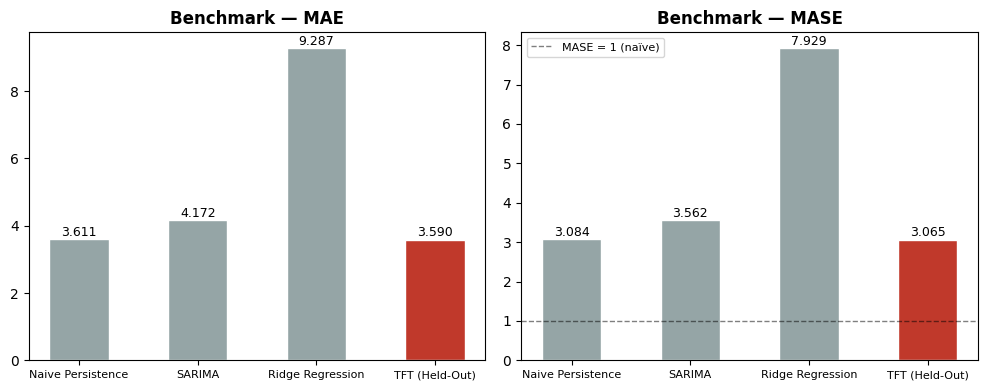

In [10]:
# Visualize benchmark
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors_b = ['#95a5a6', '#95a5a6', '#95a5a6', '#c0392b']
for ax, metric in zip(axes, ['MAE', 'MASE']):
    bars = ax.bar(bench_df['Model'], bench_df[metric], color=colors_b, edgecolor='white', width=0.5)
    ax.set_title(f'Benchmark — {metric}', fontweight='bold')
    if metric == 'MASE':
        ax.axhline(1.0, color='black', linestyle='--', lw=1, alpha=0.5, label='MASE = 1 (naïve)')
        ax.legend(fontsize=8)
    for bar, val in zip(bars, bench_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 8 · Quantile Loss, Coverage Rate, and Alignment Figures `§3.4.6`

This section computes probabilistic metrics from the held-out actual-vs-predicted table and exports the highest / middle / lowest 2022 comparison requested for the paper.


In [11]:
# ============================================================
# Quantile Loss and 80% Prediction Interval Coverage
# Computed from the held-out ground-truth alignment table
# ============================================================

QUANTILES = [0.10, 0.50, 0.90]

loss_rows = []

for _, row in gt_align_df.iterrows():
    actual = row['actual_dss']
    preds = {
        10: row['pred_q10'],
        50: row['pred_q50'],
        90: row['pred_q90'],
    }

    step_losses = []
    out_row = {
        'prov_name'     : row['prov_name'],
        'year'          : row['year'],
        'actual_value'  : actual,
        'pred_q10'      : row['pred_q10'],
        'pred_q50'      : row['pred_q50'],
        'pred_q90'      : row['pred_q90'],
        'inside_80pi'   : row['inside_80pi'],
    }

    for q in QUANTILES:
        q_int = int(q * 100)
        pred = preds[q_int]
        err = actual - pred
        pinball_loss = max(q * err, (q - 1) * err)

        out_row[f'loss_q{q_int}'] = pinball_loss
        step_losses.append(pinball_loss)

    out_row['mean_quantile_loss'] = float(np.mean(step_losses))
    loss_rows.append(out_row)

loss_df = pd.DataFrame(loss_rows)

mql_scores = [
    loss_df['loss_q10'].mean(),
    loss_df['loss_q50'].mean(),
    loss_df['loss_q90'].mean(),
]
mql_mean = float(np.mean(mql_scores))
coverage_rate = float(loss_df['inside_80pi'].mean())
total_elements = len(loss_df)

summary_df = pd.DataFrame({
    'metric': [
        'Mean Quantile Loss',
        'Pinball q10',
        'Pinball q50',
        'Pinball q90',
        'Coverage Rate 80PI',
        'Total Elements',
    ],
    'value': [
        mql_mean,
        mql_scores[0],
        mql_scores[1],
        mql_scores[2],
        coverage_rate,
        total_elements,
    ],
})

loss_csv_path = RESULTS_DIR / 'section8_actual_quantile_losses.csv'
summary_csv_path = RESULTS_DIR / 'section8_quantile_loss_summary.csv'

loss_df.to_csv(loss_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

print(f'Mean Quantile Loss (MQL) : {mql_mean:.6f}')
print(f'Pinball @ q10            : {mql_scores[0]:.6f}')
print(f'Pinball @ q50            : {mql_scores[1]:.6f}')
print(f'Pinball @ q90            : {mql_scores[2]:.6f}')
print(f'Coverage Rate (80% PI)   : {coverage_rate:.2%}  (target ≈ 80%)')
print()
print(f'Saved actual losses CSV  → {loss_csv_path}')
print(f'Saved summary CSV        → {summary_csv_path}')

display(summary_df)


Mean Quantile Loss (MQL) : 1.357605
Pinball @ q10            : 0.783990
Pinball @ q50            : 1.794906
Pinball @ q90            : 1.493919
Coverage Rate (80% PI)   : 54.63%  (target ≈ 80%)

Saved actual losses CSV  → /Users/renzo/Projects/Datubase-ph/outputs/results/section8_actual_quantile_losses.csv
Saved summary CSV        → /Users/renzo/Projects/Datubase-ph/outputs/results/section8_quantile_loss_summary.csv


,metric,value
0,Mean Quantile Loss,1.357605
1,Pinball q10,0.783990
2,Pinball q50,1.794906
3,Pinball q90,1.493919
4,Coverage Rate 80PI,0.546296
5,Total Elements,324.000000


In [12]:
# ============================================================
# Checkpoint Inventory
# This confirms that the evaluation and final forecasting checkpoints
# remain separate.
# ============================================================

from pathlib import Path

ckpt_files = sorted(MODEL_DIR.rglob('*.ckpt'))

print('Detected checkpoint files:')
for f in ckpt_files:
    marker = ''
    if 'tft_eval_best_heldout' in f.name:
        marker = '  ← use for ground-truth alignment'
    elif 'tft_final_best' in f.name or 'tft_2031_best' in f.name:
        marker = '  ← use for final future forecasts only'
    print(f'  {f}{marker}')

if not any('tft_eval_best_heldout' in f.name for f in ckpt_files):
    print('\nWarning: evaluation checkpoint not found yet. Run the held-out evaluation training cell first.')


Detected checkpoint files:
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_2031_best-v1.ckpt  ← use for final future forecasts only
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_2031_best.ckpt  ← use for final future forecasts only
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_eval_best_heldout-v1.ckpt  ← use for ground-truth alignment
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_eval_best_heldout-v2.ckpt  ← use for ground-truth alignment
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_eval_best_heldout.ckpt  ← use for ground-truth alignment
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_final_best-v1.ckpt  ← use for final future forecasts only
  /Users/renzo/Projects/Datubase-ph/outputs/models/tft_final_best.ckpt  ← use for final future forecasts only


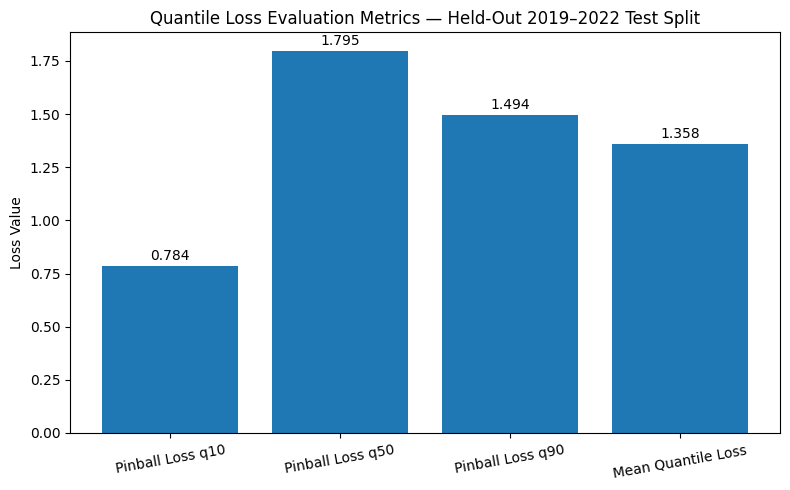

Saved CSV    → /Users/renzo/Projects/Datubase-ph/outputs/results/section8_quantile_metrics.csv
Saved Figure → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_section8_quantile_metrics.png


In [13]:
# ============================================================
# Quantile Loss Metrics Visualization
# Uses the values computed from the actual held-out predictions above.
# ============================================================

metrics_df = pd.DataFrame({
    'Metric': [
        'Pinball Loss q10',
        'Pinball Loss q50',
        'Pinball Loss q90',
        'Mean Quantile Loss',
    ],
    'Value': [
        mql_scores[0],
        mql_scores[1],
        mql_scores[2],
        mql_mean,
    ],
})

csv_path = RESULTS_DIR / 'section8_quantile_metrics.csv'
metrics_df.to_csv(csv_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics_df['Metric'], metrics_df['Value'])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f'{height:.3f}',
        ha='center',
    )

ax.set_ylabel('Loss Value')
ax.set_title('Quantile Loss Evaluation Metrics — Held-Out 2019–2022 Test Split')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()

fig_path = FIGURES_DIR / 'fig_section8_quantile_metrics.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved CSV    → {csv_path}')
print(f'Saved Figure → {fig_path}')


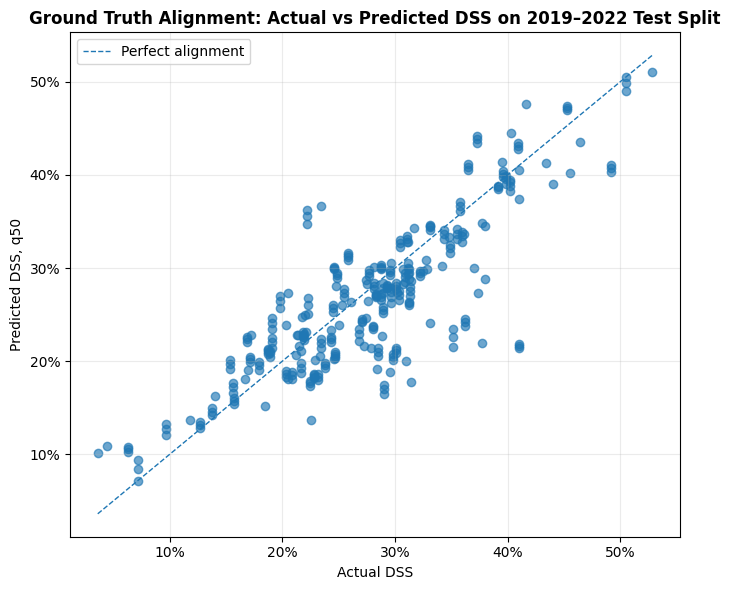

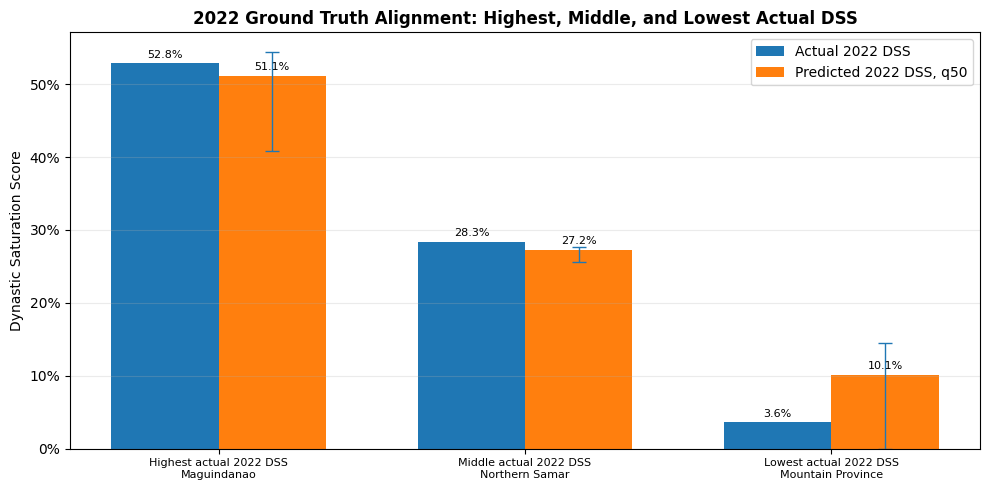

Saved scatter figure → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_ground_truth_alignment_scatter_2019_2022.png
Saved bar figure     → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_ground_truth_alignment_2022_high_mid_low.png
Saved anchor CSV     → /Users/renzo/Projects/Datubase-ph/outputs/results/ground_truth_alignment_2022_high_mid_low.csv


,comparison_group,prov_name,actual_dss,pred_q10,pred_q50,pred_q90,q50_difference_from_actual,abs_error_q50,inside_80pi
0,Highest actual 2022 DSS,Maguindanao,52.849739,40.840225,51.105427,54.394730,-1.744312,1.744312,True
1,Middle actual 2022 DSS,Northern Samar,28.346457,25.600260,27.224827,27.723812,-1.121630,1.121630,False
2,Lowest actual 2022 DSS,Mountain Province,3.603604,0.018439,10.089616,14.539323,6.486012,6.486012,True


In [ ]:
# ============================================================
# 2022 Ground Truth Alignment Bar Graphs
# Creates 3 separate bar graphs:
# 1. Top 5 highest actual 2022 DSS
# 2. Middle 5 actual 2022 DSS
# 3. Bottom 5 lowest actual 2022 DSS
#
# No retraining needed.
# Requires either:
# - gt_align_df already loaded in memory, OR
# - outputs/results/ground_truth_alignment_test_split_2019_2022.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from IPython.display import display, Image

# -----------------------------
# Infer paths if needed
# -----------------------------
try:
    RESULTS_DIR
    FIGURES_DIR
except NameError:
    CWD = Path().resolve()
    ROOT = CWD if (CWD / "outputs").exists() else CWD.parent
    RESULTS_DIR = ROOT / "outputs" / "results"
    FIGURES_DIR = ROOT / "outputs" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load ground-truth alignment data
# -----------------------------
try:
    gt_align_df
    print("Using gt_align_df already loaded in memory.")
except NameError:
    gt_path = RESULTS_DIR / "ground_truth_alignment_test_split_2019_2022.csv"

    if not gt_path.exists():
        raise FileNotFoundError(
            f"Cannot find {gt_path}. Run the ground-truth alignment cell first."
        )

    gt_align_df = pd.read_csv(gt_path)
    print(f"Loaded ground-truth alignment data from: {gt_path}")

# -----------------------------
# Keep only 2022 rows
# -----------------------------
test_2022 = (
    gt_align_df[gt_align_df["year"] == 2022]
    .copy()
    .sort_values("actual_dss", ascending=False)
    .reset_index(drop=True)
)

if test_2022.empty:
    raise ValueError("No 2022 rows found in gt_align_df.")

# -----------------------------
# Select groups
# -----------------------------
N = 5

top5 = test_2022.head(N).copy()

mid_start = max((len(test_2022) // 2) - (N // 2), 0)
middle5 = test_2022.iloc[mid_start:mid_start + N].copy()

bottom5 = (
    test_2022
    .tail(N)
    .copy()
    .sort_values("actual_dss", ascending=False)
    .reset_index(drop=True)
)

top5["group"] = "Highest"
middle5["group"] = "Middle"
bottom5["group"] = "Lowest"

selected_2022 = pd.concat(
    [top5, middle5, bottom5],
    ignore_index=True
)

selected_2022["q50_difference_from_actual"] = (
    selected_2022["pred_q50"] - selected_2022["actual_dss"]
)

selected_2022["abs_error_q50"] = (
    selected_2022["q50_difference_from_actual"].abs()
)

selected_2022["inside_80pi"] = (
    (selected_2022["actual_dss"] >= selected_2022["pred_q10"]) &
    (selected_2022["actual_dss"] <= selected_2022["pred_q90"])
)

csv_path = RESULTS_DIR / "ground_truth_alignment_2022_top5_middle5_bottom5.csv"
selected_2022.to_csv(csv_path, index=False)

display(selected_2022[
    [
        "group",
        "prov_name",
        "actual_dss",
        "pred_q10",
        "pred_q50",
        "pred_q90",
        "q50_difference_from_actual",
        "abs_error_q50",
        "inside_80pi"
    ]
])

print(f"Saved selected 2022 alignment CSV → {csv_path}")

# ============================================================
# Helper function for bar graphs
# ============================================================

def plot_2022_alignment_bar(df_group, title, filename):
    df_group = df_group.copy().reset_index(drop=True)

    x = np.arange(len(df_group))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 5.5))

    # Actual bars
    ax.bar(
        x - width / 2,
        df_group["actual_dss"],
        width,
        label="Actual 2022 DSS"
    )

    # Predicted bars
    ax.bar(
        x + width / 2,
        df_group["pred_q50"],
        width,
        label="Predicted 2022 DSS, q50"
    )

    # q10-q90 uncertainty interval for predicted values
    lower_err = np.maximum(df_group["pred_q50"] - df_group["pred_q10"], 0)
    upper_err = np.maximum(df_group["pred_q90"] - df_group["pred_q50"], 0)

    ax.errorbar(
        x + width / 2,
        df_group["pred_q50"],
        yerr=[lower_err, upper_err],
        fmt="none",
        capsize=5,
        linewidth=1
    )

    # Value labels
    for i, row in df_group.iterrows():
        ax.text(
            i - width / 2,
            row["actual_dss"] + 0.8,
            f"{row['actual_dss']:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

        ax.text(
            i + width / 2,
            row["pred_q50"] + 0.8,
            f"{row['pred_q50']:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Dynastic Saturation Score")
    ax.set_xticks(x)
    ax.set_xticklabels(df_group["prov_name"], rotation=20, ha="right")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=9)

    ymax = max(df_group["actual_dss"].max(), df_group["pred_q90"].max()) + 8
    ax.set_ylim(0, min(max(ymax, 15), 100))

    plt.tight_layout()

    fig_path = FIGURES_DIR / filename
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Force image to show under the notebook cell
    display(Image(filename=str(fig_path)))

    print(f"Saved figure → {fig_path}")

# ============================================================
# Generate the 3 separate bar graphs
# ============================================================

plot_2022_alignment_bar(
    top5,
    "2022 Ground Truth Alignment: Top 5 Highest Actual DSS Provinces",
    "fig_ground_truth_alignment_2022_top5_highest.png"
)

plot_2022_alignment_bar(
    middle5,
    "2022 Ground Truth Alignment: Middle 5 Actual DSS Provinces",
    "fig_ground_truth_alignment_2022_middle5.png"
)

plot_2022_alignment_bar(
    bottom5,
    "2022 Ground Truth Alignment: Bottom 5 Lowest Actual DSS Provinces",
    "fig_ground_truth_alignment_2022_bottom5_lowest.png"
)

In [15]:
# ============================================================
# Final TFT Training on Complete 2000–2022 Panel
# This model is used only after held-out evaluation is complete.
# It is the correct model for 2028 and 2031 future forecasting.
# It uses all possible historical training windows after the encoder has enough context.
# ============================================================

final_params = best_params.copy()
BEST_BATCH_SIZE = int(final_params.pop('batch_size', BATCH_SIZE))

full_dataset = TimeSeriesDataSet(
    df_hist,
    min_prediction_idx    = MIN_TRAIN_PRED_IDX,
    max_prediction_length = PRED_LENGTH_28,
    **_ds_kwargs,
)

full_loader = full_dataset.to_dataloader(
    train=True,
    batch_size=BEST_BATCH_SIZE,
    num_workers=0,
)

final_model = build_tft(full_dataset, **final_params)

checkpoint_cb = ModelCheckpoint(
    dirpath=str(MODEL_DIR),
    filename='tft_final_best',
    monitor='train_loss',
    mode='min',
    save_top_k=1,
)

# Final model uses all observed history, so there is no held-out validation set here.
# This checkpoint must not be used for ground-truth alignment.
early_stop_cb = EarlyStopping(
    monitor='train_loss',
    patience=10,
    mode='min',
    verbose=False,
)

csv_logger = CSVLogger(
    save_dir=str(OUT_DIR / 'logs'),
    name='tft_final',
)

trainer_final = pl.Trainer(
    max_epochs=100,
    gradient_clip_val=0.01,
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=csv_logger,
    enable_progress_bar=True,
)

trainer_final.fit(final_model, train_dataloaders=full_loader)

best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_cb.best_model_path)
best_model.eval()

print(f'Final full-history forecast checkpoint: {checkpoint_cb.best_model_path}')
print('Use this checkpoint for 2028/2031 forecasts only, not test-split validation.')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 1.3 K  | train | 0    
3  | prescalers                         | ModuleDict                      | 512    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 5.0 K  | train

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Final full-history forecast checkpoint: /Users/renzo/Projects/Datubase-ph/outputs/models/tft_final_best-v2.ckpt
Use this checkpoint for 2028/2031 forecasts only, not test-split validation.


---
## 9 · Final Full-History Training + Forecast Generation — 2028 & 2031 Horizons `§3.4.7`

After held-out evaluation, the final TFT is retrained on the complete 2000–2022 panel for future forecasting.


In [16]:
# §3.4.7 — IRA forward-projection assumption (Mandanas-Garcia NTA framework)
IRA_ANNUAL_GROWTH_RATE = 1.06   # 6% nominal annual growth; see Scope and Delimitations

def build_forecast_df(df_hist: pd.DataFrame, pred_length: int) -> pd.DataFrame:
    """Append synthetic future rows to historical panel for inference."""
    last_idx = int(df_hist['time_idx'].max())
    rows = []

    for prov in PROVINCES:
        last_row = df_hist[df_hist['prov_name'] == prov].sort_values('time_idx').iloc[-1]

        for step in range(1, pred_length + 1):
            rows.append({
                'prov_name'              : prov,
                'year'                   : 2022 + step,
                # Dummy target value required by TimeSeriesDataSet for future rows.
                # It is not used as the actual forecast output.
                'dynasty_share'          : float(last_row['dynasty_share']),
                'gov_is_dynasty'         : str(last_row['gov_is_dynasty']),
                'vice_gov_is_dynasty'    : str(last_row['vice_gov_is_dynasty']),
                'ira_funding_million_php': float(last_row['ira_funding_million_php']) * (IRA_ANNUAL_GROWTH_RATE ** step),
                'time_idx'               : last_idx + step,
                'poverty_incidence'      : float(last_row['poverty_incidence']),
            })

    df_fut = pd.DataFrame(rows)
    return pd.concat([df_hist, df_fut], ignore_index=True)


def run_inference(model, base_dataset, df_combined, pred_length, label):
    ds = TimeSeriesDataSet.from_dataset(
        base_dataset,
        df_combined,
        min_prediction_length=pred_length,
        max_prediction_length=pred_length,
        predict=True,
        stop_randomization=True,
    )

    loader = ds.to_dataloader(
        train=False,
        batch_size=BEST_BATCH_SIZE,
        num_workers=0,
    )

    raw_pred = model.predict(loader, mode='raw', return_x=True)
    preds = raw_pred.output.prediction.detach().cpu().numpy()

    records = []
    for i, prov in enumerate(PROVINCES):
        for h in range(pred_length):
            records.append({
                'prov_name'         : prov,
                'year'              : 2022 + h + 1,
                'q10_dynasty_share' : float(np.clip(preds[i, h, 0], 0, 100)),
                'q50_dynasty_share' : float(np.clip(preds[i, h, 1], 0, 100)),
                'q90_dynasty_share' : float(np.clip(preds[i, h, 2], 0, 100)),
                'horizon'           : int(label),
            })

    return pd.DataFrame(records)


# ── 2028 primary horizon ─────────────────────────────────────────────────────
print('Generating 2028 forecasts…')
fc_2028 = run_inference(
    best_model,
    full_dataset,
    build_forecast_df(df_hist, PRED_LENGTH_28),
    PRED_LENGTH_28,
    2028,
)

# ── 2031 extended horizon — separate full-history model with pred_length=9 ───
print('Training extended model for 2031 horizon…')

full_ds_31 = TimeSeriesDataSet(
    df_hist,
    min_prediction_idx    = MIN_TRAIN_PRED_IDX,
    max_prediction_length = PRED_LENGTH_31,
    **_ds_kwargs,
)

params_31 = best_params.copy()
BATCH_SIZE_31 = int(params_31.pop('batch_size', BATCH_SIZE))

loader_31_train = full_ds_31.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE_31,
    num_workers=0,
)

model_31 = build_tft(full_ds_31, **params_31)

ckpt_31 = ModelCheckpoint(
    dirpath=str(MODEL_DIR),
    filename='tft_2031_best',
    monitor='train_loss',
    mode='min',
    save_top_k=1,
)

trainer_31 = pl.Trainer(
    max_epochs=100,
    gradient_clip_val=0.01,
    callbacks=[
        ckpt_31,
        EarlyStopping(monitor='train_loss', patience=10, mode='min', verbose=False),
    ],
    logger=False,
    enable_progress_bar=True,
)

trainer_31.fit(model_31, train_dataloaders=loader_31_train)

model_31_best = TemporalFusionTransformer.load_from_checkpoint(ckpt_31.best_model_path)
model_31_best.eval()

print('Generating 2031 forecasts…')
fc_2031 = run_inference(
    model_31_best,
    full_ds_31,
    build_forecast_df(df_hist, PRED_LENGTH_31),
    PRED_LENGTH_31,
    2031,
)

# ── Combine and export ───────────────────────────────────────────────────────
fc_all = (
    pd.concat([fc_2028, fc_2031], ignore_index=True)
    .drop_duplicates(subset=['prov_name', 'year', 'horizon'])
)

fc_path = RESULTS_DIR / 'tft_forecast_output.csv'
fc_all.to_csv(fc_path, index=False)

print(f'\nForecast output → {fc_path} ({len(fc_all):,} rows)')
display(fc_all.head(10))


Generating 2028 forecasts…


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
-----------------------------------------------------------------------------

Training extended model for 2031 horizon…


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Generating 2031 forecasts…

Forecast output → /Users/renzo/Projects/Datubase-ph/outputs/results/tft_forecast_output.csv (1,215 rows)


,prov_name,year,q10_dynasty_share,q50_dynasty_share,q90_dynasty_share,horizon
0,Abra,2023,35.341953,36.595261,38.092731,2028
1,Abra,2024,35.223190,36.962273,38.833492,2028
2,Abra,2025,35.365307,37.649879,40.069363,2028
3,Abra,2026,35.568218,38.371967,41.402275,2028
4,Abra,2027,35.672989,38.801205,42.270576,2028
5,Abra,2028,35.667412,38.944897,42.656174,2028
6,Agusan Del Norte,2023,19.731031,21.321692,23.180029,2028
7,Agusan Del Norte,2024,19.485134,21.155092,23.112345,2028
8,Agusan Del Norte,2025,19.227093,20.964581,22.996351,2028
9,Agusan Del Norte,2026,19.000366,20.783070,22.868343,2028


---
## 10 · Interpretability `§3.4.8`
### 10A · Variable Importance (VSN weights)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


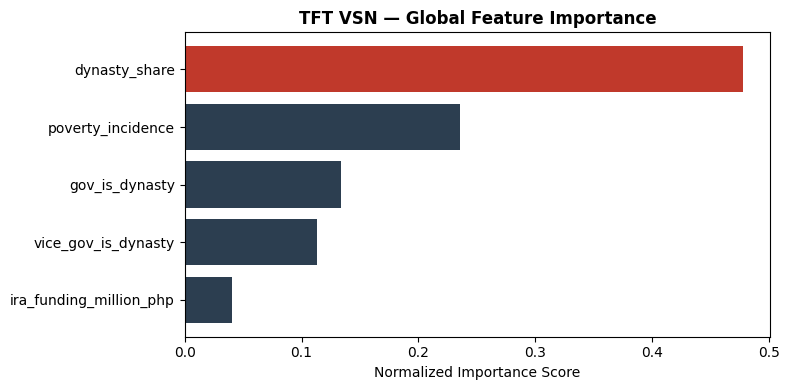

Variable importance CSV → /Users/renzo/Projects/Datubase-ph/outputs/results/tft_variable_importance.csv


,variable_name,global_importance_score
4,dynasty_share,0.477267
6,poverty_incidence,0.235651
0,gov_is_dynasty,0.133511
1,vice_gov_is_dynasty,0.112893
5,ira_funding_million_php,0.040677


In [17]:
# ============================================================
# Variable Importance (VSN weights)
# Uses the final full-history 2028 model.
# ============================================================

vi_dataset = TimeSeriesDataSet.from_dataset(
    full_dataset,
    df_hist,
    min_prediction_idx=df_hist['time_idx'].min(),
    max_prediction_length=PRED_LENGTH_28,
    predict=False,
    stop_randomization=True,
)

vi_loader = vi_dataset.to_dataloader(
    train=False,
    batch_size=BEST_BATCH_SIZE,
    num_workers=0,
)

raw_out_vi = best_model.predict(vi_loader, mode='raw', return_x=True)
interpretation = best_model.interpret_output(raw_out_vi.output, reduction='mean')

if 'encoder_variables' not in interpretation:
    raise KeyError(f"encoder_variables not found. Available keys: {list(interpretation.keys())}")

importance_scores = interpretation['encoder_variables'].detach().cpu().numpy()
variable_names = best_model.encoder_variables

var_imp = pd.DataFrame({
    'variable_name': variable_names,
    'global_importance_score': importance_scores,
})

# Filter out internal timing variables if they appear.
vars_to_remove = ['time_idx', 'relative_time_idx', 'year']
var_imp = var_imp[~var_imp['variable_name'].isin(vars_to_remove)].copy()

# Re-normalize so the remaining features sum to 1.0.
score_sum = var_imp['global_importance_score'].sum()
if score_sum != 0:
    var_imp['global_importance_score'] = var_imp['global_importance_score'] / score_sum

var_imp = var_imp.sort_values('global_importance_score', ascending=False)

vi_path = RESULTS_DIR / 'tft_variable_importance.csv'
var_imp.to_csv(vi_path, index=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_vi = ['#c0392b' if i == 0 else '#2c3e50' for i in range(len(var_imp))]
ax.barh(var_imp['variable_name'], var_imp['global_importance_score'], color=colors_vi)
ax.set_xlabel('Normalized Importance Score')
ax.set_title('TFT VSN — Global Feature Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()

fig_path = FIGURES_DIR / 'fig_variable_importance.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Variable importance CSV → {vi_path}')
display(var_imp)


In [18]:
# ============================================================
# Export Temporal Attention Weights for Dashboard / Heatmap
# Uses the SAME final full-history 2028 forecast window.
#
# Important correction:
# ENCODER_LENGTH = 9, so the final 2028 forecast can only attend
# to the last 9 observed encoder years, normally 2014–2022.
# Do NOT fabricate 2000–2013 attention values and do NOT impute 2000.
#
# Version-safe fix:
# Some PyTorch Forecasting versions do not return encoder_time_idx in
# raw_out.x. When missing, this cell reconstructs encoder time indices
# from decoder_time_idx + encoder_lengths instead.
# ============================================================

import numpy as np
import pandas as pd
import torch

# Build the same future-extended dataframe used for the 2028 forecast.
df_future_28 = build_forecast_df(df_hist, PRED_LENGTH_28)

attention_dataset_28 = TimeSeriesDataSet.from_dataset(
    full_dataset,
    df_future_28,
    predict=True,
    stop_randomization=True,
    min_prediction_length=PRED_LENGTH_28,
    max_prediction_length=PRED_LENGTH_28,
)

attention_loader_28 = attention_dataset_28.to_dataloader(
    train=False,
    batch_size=BEST_BATCH_SIZE,
    num_workers=0,
)

raw_out_attn = best_model.predict(
    attention_loader_28,
    mode='raw',
    return_x=True,
)

interpretation_none = best_model.interpret_output(
    raw_out_attn.output,
    reduction='none',
)

if 'attention' not in interpretation_none:
    raise KeyError(
        "Could not find 'attention' in TFT interpretation output. "
        f"Available keys: {list(interpretation_none.keys())}"
    )

attention = interpretation_none['attention'].detach().cpu()
x_attn = raw_out_attn.x

print('Available raw_out.x keys:', list(x_attn.keys()))
print('Raw interpretation attention shape:', tuple(attention.shape))

# ------------------------------------------------------------
# 1. Reduce attention tensor to [samples, attention_positions]
# ------------------------------------------------------------
# Depending on PyTorch Forecasting version, attention can include
# decoder horizon and/or attention-head dimensions. Averaging extra
# dimensions gives one mean attention profile per province/sample.
while attention.ndim > 2:
    attention = attention.mean(dim=1)

print('Reduced attention shape:', tuple(attention.shape))

# ------------------------------------------------------------
# 2. Recover encoder time indices robustly
# ------------------------------------------------------------
# Preferred: use encoder_time_idx directly if available.
# Fallback: derive encoder indices from decoder start and encoder length.
if 'encoder_time_idx' in x_attn:
    encoder_time_idx = x_attn['encoder_time_idx'].detach().cpu().long()
else:
    if 'encoder_lengths' not in x_attn:
        raise KeyError(
            "Neither 'encoder_time_idx' nor 'encoder_lengths' is available in raw prediction x output. "
            f"Available keys: {list(x_attn.keys())}"
        )

    encoder_lengths = x_attn['encoder_lengths'].detach().cpu().long()
    max_encoder_len = int(encoder_lengths.max().item())

    if 'decoder_time_idx' in x_attn:
        decoder_start_idx = x_attn['decoder_time_idx'][:, 0].detach().cpu().long()
    else:
        # PyTorch Forecasting's x_to_index usually returns the first decoder time_idx.
        index_tmp = attention_dataset_28.x_to_index(x_attn).reset_index(drop=True)
        if 'time_idx' not in index_tmp.columns:
            raise KeyError(
                "Cannot reconstruct encoder time indices because both 'decoder_time_idx' "
                "and x_to_index(...)[time_idx] are unavailable."
            )
        decoder_start_idx = torch.tensor(index_tmp['time_idx'].astype(int).values, dtype=torch.long)

    encoder_time_idx = torch.zeros((len(encoder_lengths), max_encoder_len), dtype=torch.long)
    for i, enc_len in enumerate(encoder_lengths.tolist()):
        start = int(decoder_start_idx[i].item()) - int(enc_len)
        end = int(decoder_start_idx[i].item())
        idxs = torch.arange(start, end, dtype=torch.long)

        # Right-align to max_encoder_len so shorter sequences, if any, remain padded at left.
        encoder_time_idx[i, -len(idxs):] = idxs

print('Recovered encoder_time_idx shape:', tuple(encoder_time_idx.shape))

# ------------------------------------------------------------
# 3. Align attention positions to encoder positions
# ------------------------------------------------------------
enc_len = encoder_time_idx.shape[1]
attn_len = attention.shape[1]

if attn_len == enc_len:
    encoder_attention = attention
elif attn_len > enc_len:
    # TFT interpret_output may include encoder + decoder temporal positions.
    # Encoder years are the first enc_len positions; decoder/future years are excluded.
    encoder_attention = attention[:, :enc_len]
    print(
        f'Attention had {attn_len} positions; kept first {enc_len} encoder positions '
        'and excluded decoder/future positions.'
    )
else:
    # Rare case: attention has fewer positions than the recovered encoder index.
    # Keep the rightmost encoder years to match the available attention length.
    encoder_time_idx = encoder_time_idx[:, -attn_len:]
    encoder_attention = attention
    print(
        f'Attention had only {attn_len} positions; aligned to the rightmost '
        f'{attn_len} encoder years.'
    )

if encoder_attention.shape[1] != encoder_time_idx.shape[1]:
    raise ValueError(
        f'Encoder attention length ({encoder_attention.shape[1]}) does not match '
        f'encoder_time_idx length ({encoder_time_idx.shape[1]}).'
    )

# Replace NaN/inf values produced by masked attention with zeros before normalization.
encoder_attention = torch.nan_to_num(encoder_attention, nan=0.0, posinf=0.0, neginf=0.0)

index_df = attention_dataset_28.x_to_index(x_attn).reset_index(drop=True)

time_idx_to_year = (
    df_future_28[['time_idx', 'year']]
    .drop_duplicates()
    .set_index('time_idx')['year']
    .to_dict()
)

# ------------------------------------------------------------
# 4. Export long and wide attention tables
# ------------------------------------------------------------
attn_records = []
for i in range(encoder_attention.shape[0]):
    prov_name = index_df.iloc[i]['prov_name']

    sample_weights = encoder_attention[i].numpy().astype(float)
    sample_sum = sample_weights.sum()
    if sample_sum > 0:
        sample_weights = sample_weights / sample_sum

    for j in range(encoder_attention.shape[1]):
        t_idx = int(encoder_time_idx[i, j].item())
        year = int(time_idx_to_year.get(t_idx, 2000 + t_idx))

        # Keep only observed historical encoder years.
        if 2000 <= year <= 2022:
            attn_records.append({
                'prov_name': prov_name,
                'encoder_year': year,
                'attention_weight': float(sample_weights[j]),
            })

attn_long = pd.DataFrame(attn_records)

if attn_long.empty:
    raise ValueError(
        'No attention records were generated. Check recovered encoder years and interpretation output.'
    )

# Mean is defensive in case duplicate province-year rows occur.
attn_year = (
    attn_long
    .groupby(['prov_name', 'encoder_year'], as_index=False)['attention_weight']
    .mean()
)

actual_encoder_years = sorted(attn_year['encoder_year'].unique().astype(int).tolist())
print(f'Actual encoder years used in 2028 forecast attention: {actual_encoder_years}')

# Export only years that actually appear in the final 2028 forecast encoder window.
# With ENCODER_LENGTH=9 this should normally be 2014–2022.
attn_wide = (
    attn_year
    .pivot(index='prov_name', columns='encoder_year', values='attention_weight')
    .reindex(index=PROVINCES, columns=actual_encoder_years)
    .fillna(0.0)
)

# Row-normalize defensively after pivoting.
row_sums = attn_wide.sum(axis=1).replace(0, 1)
attn_norm = attn_wide.div(row_sums, axis=0)

attn_export = attn_norm.copy()
attn_export.columns = [f'attention_weight_{int(c)}' for c in attn_export.columns]
attn_export.insert(0, 'prov_name', attn_export.index)
attn_export['forecast_horizon_year'] = 2028
attn_export['encoder_year_start'] = min(actual_encoder_years)
attn_export['encoder_year_end'] = max(actual_encoder_years)
attn_export['encoder_length_actual'] = len(actual_encoder_years)

attn_path = RESULTS_DIR / 'tft_attention_weights.csv'
attn_export.to_csv(attn_path, index=False)

# Save long format too, useful for Tableau and debugging.
attn_long_path = RESULTS_DIR / 'tft_attention_weights_long.csv'
attn_long.to_csv(attn_long_path, index=False)

coverage_summary = pd.DataFrame({
    'forecast_horizon_year': [2028],
    'configured_encoder_length': [ENCODER_LENGTH],
    'actual_encoder_year_start': [min(actual_encoder_years)],
    'actual_encoder_year_end': [max(actual_encoder_years)],
    'actual_encoder_years': [', '.join(map(str, actual_encoder_years))],
    'note': [
        'The 2028 attention heatmap uses only the years present in the final forecast encoder window. '
        'Earlier years are not imputed because the TFT encoder length is 9.'
    ],
})
coverage_path = RESULTS_DIR / 'tft_attention_year_coverage_summary.csv'
coverage_summary.to_csv(coverage_path, index=False)

print(f'Attention weights exported      → {attn_path}')
print(f'Long attention weights exported → {attn_long_path}')
print(f'Coverage summary exported       → {coverage_path}')
display(attn_export.head())
display(coverage_summary)



GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Available raw_out.x keys: ['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale']
Raw interpretation attention shape: (81, 9)
Reduced attention shape: (81, 9)
Recovered encoder_time_idx shape: (81, 9)
Actual encoder years used in 2028 forecast attention: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Attention weights exported      → /Users/renzo/Projects/Datubase-ph/outputs/results/tft_attention_weights.csv
Long attention weights exported → /Users/renzo/Projects/Datubase-ph/outputs/results/tft_attention_weights_long.csv
Coverage summary exported       → /Users/renzo/Projects/Datubase-ph/outputs/results/tft_attention_year_coverage_summary.csv


,prov_name,attention_weight_2014,attention_weight_2015,attention_weight_2016,attention_weight_2017,attention_weight_2018,attention_weight_2019,attention_weight_2020,attention_weight_2021,attention_weight_2022,forecast_horizon_year,encoder_year_start,encoder_year_end,encoder_length_actual
prov_name,,,,,,,,,,,,,,
Abra,Abra,0.062732,0.052203,0.080631,0.079532,0.078114,0.068471,0.069462,0.071972,0.436883,2028,2014,2022,9
Agusan Del Norte,Agusan Del Norte,0.112557,0.089382,0.048631,0.050765,0.055805,0.163952,0.176293,0.184665,0.117951,2028,2014,2022,9
Agusan Del Sur,Agusan Del Sur,0.135070,0.143388,0.146121,0.121037,0.103535,0.041046,0.039246,0.038012,0.232546,2028,2014,2022,9
Aklan,Aklan,0.180284,0.134090,0.090799,0.086741,0.088218,0.088470,0.090398,0.093288,0.147712,2028,2014,2022,9
Albay,Albay,0.043869,0.054949,0.029887,0.027561,0.027357,0.041876,0.045036,0.046969,0.682496,2028,2014,2022,9


,forecast_horizon_year,configured_encoder_length,actual_encoder_year_start,actual_encoder_year_end,actual_encoder_years,note
0,2028,9,2014,2022,"2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021...",The 2028 attention heatmap uses only the years...


### 10B · Temporal Attention Weight Heatmap

Heatmap years shown: 2014–2022
Number of encoder years shown: 9
Note: 2000 is not shown because it was not part of the final forecast encoder window.


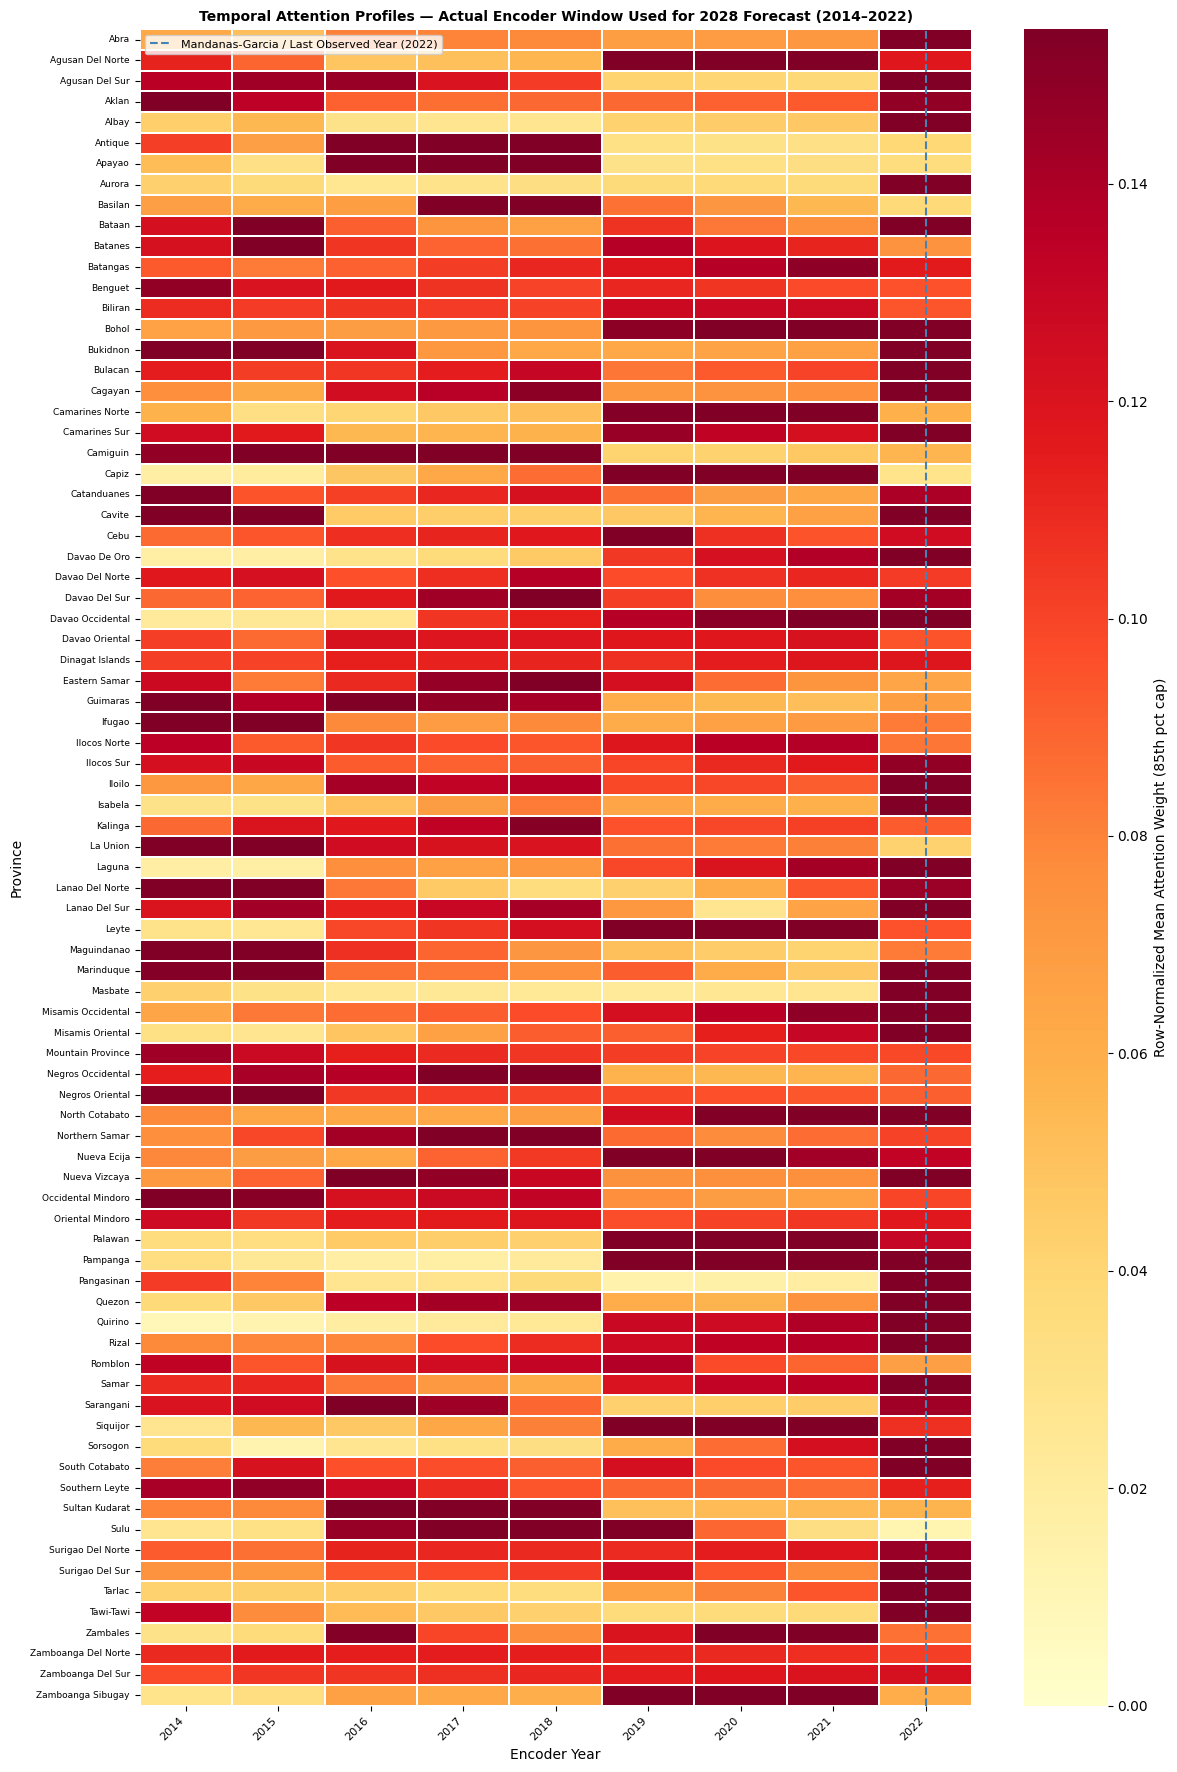

Heatmap saved → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_attention_heatmap.png
Normalized attention CSV saved without year imputation → /Users/renzo/Projects/Datubase-ph/outputs/results/tft_attention_weights.csv


In [19]:
# ============================================================
# §3.4.8 — Temporal Attention Weight Heatmap
# Uses only the encoder years that actually existed in the
# final 2028 forecast attention extraction.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CWD         = Path().resolve()
ROOT        = CWD if (CWD / 'data' / 'final').exists() else CWD.parent
RESULTS_DIR = ROOT / 'outputs' / 'results'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

attn_path = RESULTS_DIR / 'tft_attention_weights.csv'
if not attn_path.exists():
    raise FileNotFoundError(
        f'{attn_path} not found. Run the attention export cell immediately before this cell first.'
    )

attn_df = pd.read_csv(attn_path)

# Detect only actual exported attention columns.
attn_cols = [c for c in attn_df.columns if c.startswith('attention_weight_')]
HIST_YEARS = [int(c.split('_')[-1]) for c in attn_cols]

if not attn_cols:
    raise ValueError('No attention_weight_* columns found in tft_attention_weights.csv.')

attn_df = attn_df.sort_values('prov_name').reset_index(drop=True)
attn_wide = attn_df.set_index('prov_name')[attn_cols].copy()

# Row-normalize defensively in case the CSV was edited externally.
row_sums = attn_wide.sum(axis=1).replace(0, 1)
attn_norm = attn_wide.div(row_sums, axis=0)

# Diagnostic printout: this prevents accidentally claiming 2000–2022 if only 2014–2022 exists.
print(f'Heatmap years shown: {min(HIST_YEARS)}–{max(HIST_YEARS)}')
print(f'Number of encoder years shown: {len(HIST_YEARS)}')
if 2000 not in HIST_YEARS:
    print('Note: 2000 is not shown because it was not part of the final forecast encoder window.')

vmax = np.percentile(attn_norm.values.flatten(), 85)

n_provs = len(attn_df)
fig, ax = plt.subplots(figsize=(12, max(8, n_provs * 0.22)))

sns.heatmap(
    attn_norm.values,
    ax=ax,
    xticklabels=[str(y) for y in HIST_YEARS],
    yticklabels=attn_df['prov_name'].tolist(),
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax,
    linewidths=0.15,
    linecolor='white',
    cbar_kws={'label': 'Row-Normalized Mean Attention Weight (85th pct cap)'},
)

ax.set_title(
    f'Temporal Attention Profiles — Actual Encoder Window Used for 2028 Forecast ({min(HIST_YEARS)}–{max(HIST_YEARS)})',
    fontweight='bold',
    fontsize=10,
)
ax.set_xlabel('Encoder Year')
ax.set_ylabel('Province')

if 2022 in HIST_YEARS:
    mandanas_x = HIST_YEARS.index(2022) + 0.5
    ax.axvline(mandanas_x, color='steelblue', lw=1.5, linestyle='--', label='Mandanas-Garcia / Last Observed Year (2022)')
    ax.legend(fontsize=8, loc='upper left')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=6.5)
plt.tight_layout()

out_path = FIGURES_DIR / 'fig_attention_heatmap.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

# Save normalized form back to CSV for Tableau consistency, but do not impute missing years.
attn_export = attn_norm.copy()
attn_export.insert(0, 'prov_name', attn_export.index)
attn_export['forecast_horizon_year'] = 2028
attn_export['encoder_year_start'] = min(HIST_YEARS)
attn_export['encoder_year_end'] = max(HIST_YEARS)
attn_export['encoder_length_actual'] = len(HIST_YEARS)
attn_export.to_csv(attn_path, index=False)

print(f'Heatmap saved → {out_path}')
print(f'Normalized attention CSV saved without year imputation → {attn_path}')



---
## 11 · Risk Tier Classification + Dashboard Export `§3.6.2`

In [20]:
# ============================================================
# §3.6.2 — Risk Tier Classification + Dashboard Export
# STANDALONE: loads from tft_forecast_output.csv and
# tft_master_dataset.csv. No model required.
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
CWD         = Path().resolve()
ROOT        = CWD if (CWD / 'data' / 'final').exists() else CWD.parent
DATA_DIR    = ROOT / 'data' / 'final'
RESULTS_DIR = ROOT / 'outputs' / 'results'

# ── Load dependencies ─────────────────────────────────────────
fc_all  = pd.read_csv(RESULTS_DIR / 'tft_forecast_output.csv')
df_hist = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')
df_hist = df_hist[df_hist['year'] <= 2022].copy()

# Ensure horizon is int
fc_all['horizon'] = fc_all['horizon'].astype(int)

print(f'Forecast rows     : {len(fc_all):,}')
print(f'Horizon values    : {sorted(fc_all["horizon"].unique())}')
print(f'Year range        : {fc_all["year"].min()}–{fc_all["year"].max()}')
print(f'Provinces         : {fc_all["prov_name"].nunique()}')

# ── Risk tier function ────────────────────────────────────────
def assign_risk_tier(q50: float) -> str:
    if q50 < 33:   return 'Low Risk'
    elif q50 < 50: return 'Moderate Risk'
    elif q50 < 70: return 'High Risk'
    else:          return 'Critical Capture Risk'

# ── Build dashboard dataframe ─────────────────────────────────
baseline_2022 = (
    df_hist[df_hist['year'] == 2022]
    .set_index('prov_name')['dynasty_share']
    .rename('dynasty_share_2022')
)

dash_df = fc_all.copy()
dash_df['risk_tier']       = dash_df['q50_dynasty_share'].apply(assign_risk_tier)
dash_df['pi_width']        = dash_df['q90_dynasty_share'] - dash_df['q10_dynasty_share']
dash_df                    = dash_df.join(baseline_2022, on='prov_name')
dash_df['delta_from_2022'] = dash_df['q50_dynasty_share'] - dash_df['dynasty_share_2022']
dash_df['trajectory']      = dash_df['delta_from_2022'].apply(
    lambda d: 'Increasing' if d > 2 else ('Decreasing' if d < -2 else 'Stable')
)

dash_df.to_csv(RESULTS_DIR / 'dashboard_forecast_final.csv', index=False)

# ── Summary ───────────────────────────────────────────────────
for yr_val in [2028, 2031]:
    # For each horizon, show the single forecast-year row per province
    sub = dash_df[(dash_df['horizon'] == yr_val) & (dash_df['year'] == yr_val)]
    if sub.empty:
        print(f'\n── {yr_val}: no rows found')
        continue
    print(f'\n── {yr_val} Risk Distribution ({len(sub)} provinces) ──')
    print(sub['risk_tier'].value_counts().to_string())
    print(f'   Mean q50 : {sub["q50_dynasty_share"].mean():.2f}%')

print(f'\nDashboard CSV → {RESULTS_DIR}/dashboard_forecast_final.csv')
print(f'Total rows saved  : {len(dash_df):,}')

Forecast rows     : 1,215
Horizon values    : [np.int64(2028), np.int64(2031)]
Year range        : 2023–2031
Provinces         : 81

── 2028 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         54
Moderate Risk    26
High Risk         1
   Mean q50 : 30.53%

── 2031 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         58
Moderate Risk    22
High Risk         1
   Mean q50 : 29.89%

Dashboard CSV → /Users/renzo/Projects/Datubase-ph/outputs/results/dashboard_forecast_final.csv
Total rows saved  : 1,215


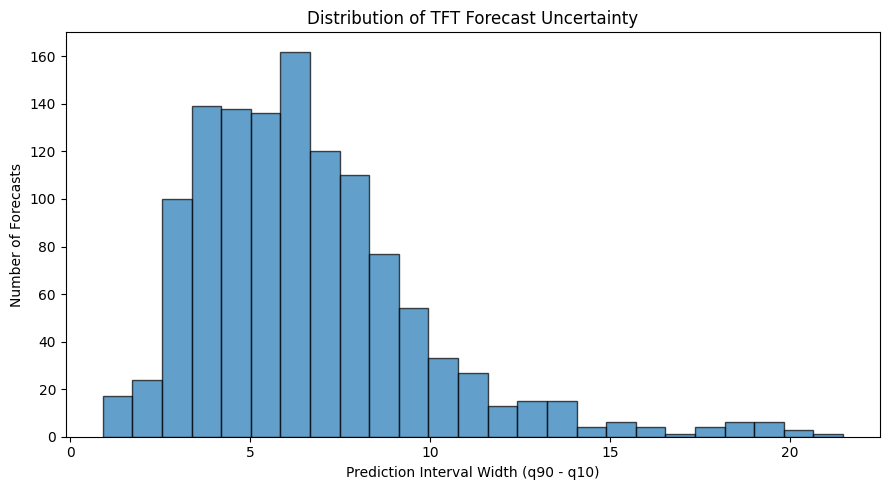

Saved CSV    → /Users/renzo/Projects/Datubase-ph/outputs/results/section8_forecast_uncertainty_distribution.csv
Saved Figure → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_forecast_uncertainty_distribution.png


In [21]:
# ============================================================
# Forecast Uncertainty Distribution
# Uses dashboard_forecast_final.csv after risk-tier export.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

forecast_path = RESULTS_DIR / 'dashboard_forecast_final.csv'

if not forecast_path.exists():
    raise FileNotFoundError(
        f'{forecast_path} not found. Run the dashboard export cell first.'
    )

uncertainty_df = pd.read_csv(forecast_path)

if 'pi_width' not in uncertainty_df.columns:
    uncertainty_df['pi_width'] = (
        uncertainty_df['q90_dynasty_share'] - uncertainty_df['q10_dynasty_share']
    )

uncertainty_csv = RESULTS_DIR / 'section8_forecast_uncertainty_distribution.csv'
uncertainty_df.to_csv(uncertainty_csv, index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(uncertainty_df['pi_width'], bins=25, edgecolor='black', alpha=0.7)
ax.set_title('Distribution of TFT Forecast Uncertainty')
ax.set_xlabel('Prediction Interval Width (q90 - q10)')
ax.set_ylabel('Number of Forecasts')
plt.tight_layout()

fig_path = FIGURES_DIR / 'fig_forecast_uncertainty_distribution.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved CSV    → {uncertainty_csv}')
print(f'Saved Figure → {fig_path}')


  Pearson Correlations with Dynasty Share
  IRA Funding (M PHP)           r = +0.3929
  Gov is Dynasty                r = +0.2816
  Vice Gov is Dynasty           r = +0.2564
  Poverty Incidence             r = -0.2033

  Spearman Correlations with Dynasty Share
  IRA Funding (M PHP)           ρ = +0.4216
  Vice Gov is Dynasty           ρ = +0.2682
  Gov is Dynasty                ρ = +0.2664
  Poverty Incidence             ρ = -0.2381


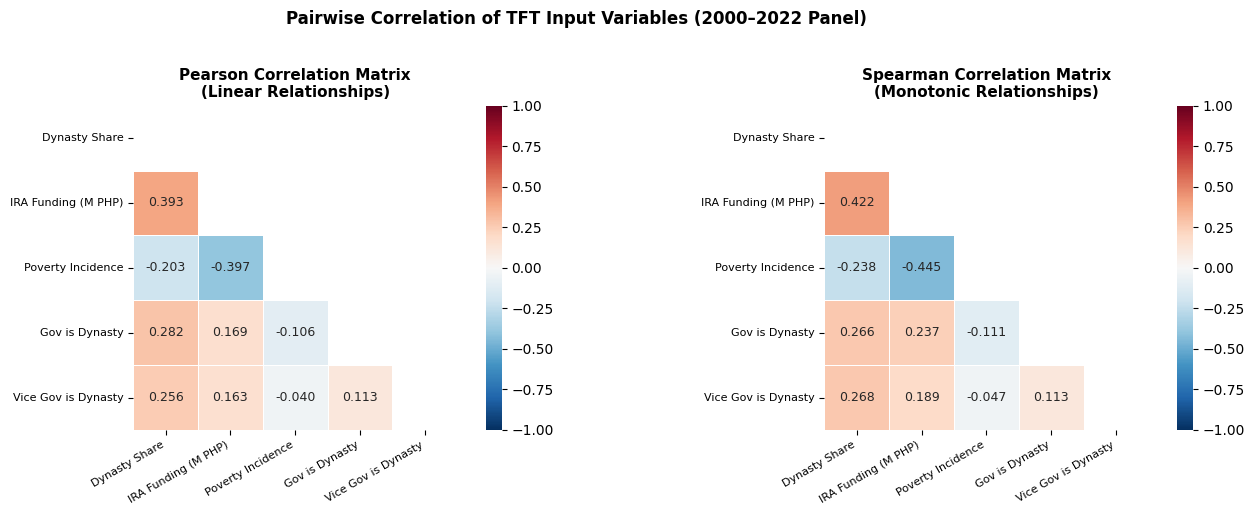


Figure saved → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_correlation_heatmap.png


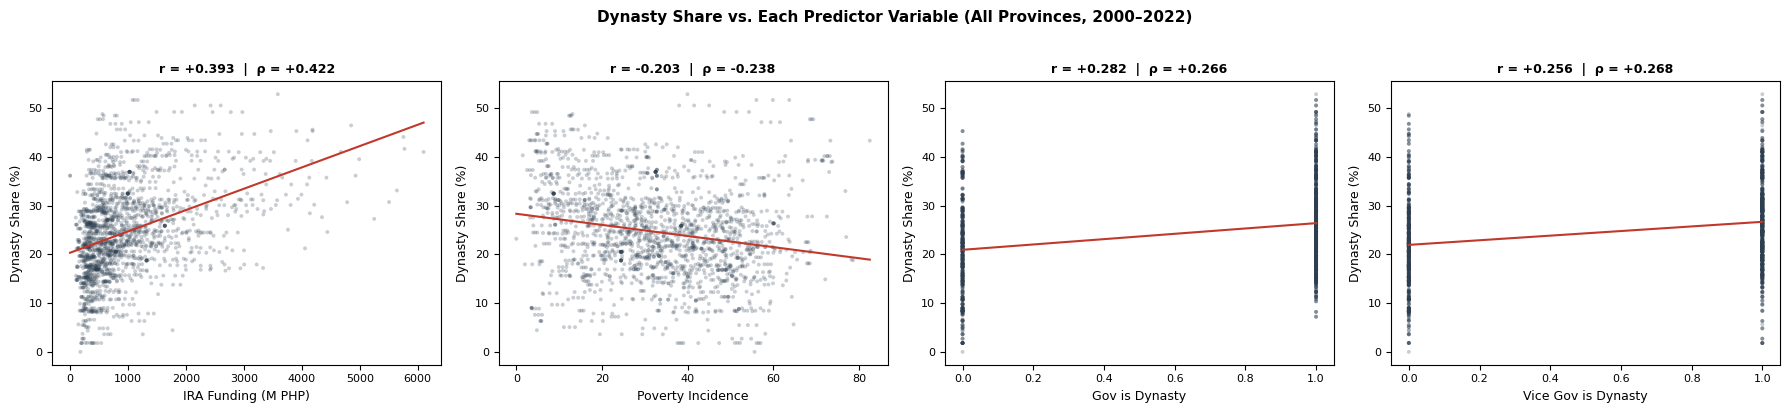

Figure saved → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_correlation_scatter.png


In [22]:
# ── Correlation Analysis of TFT Input Variables ─────────────────────────────
# Self-contained: re-loads the master dataset independently.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# ── Paths (mirrors Cell 0 convention) ────────────────────────────────────────
CWD         = Path().resolve()
ROOT        = CWD if (CWD / 'data' / 'final').exists() else CWD.parent
DATA_DIR    = ROOT / 'data' / 'final'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load master dataset ───────────────────────────────────────────────────────
df_corr = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')

# ── Encode binary categorical flags as integers for correlation ───────────────
# gov_is_dynasty and vice_gov_is_dynasty are stored as strings ('0'/'1')
df_corr['gov_is_dynasty']      = df_corr['gov_is_dynasty'].astype(int)
df_corr['vice_gov_is_dynasty'] = df_corr['vice_gov_is_dynasty'].astype(int)

# ── Select the five model variables ──────────────────────────────────────────
VARS = [
    'dynasty_share',
    'ira_funding_million_php',
    'poverty_incidence',
    'gov_is_dynasty',
    'vice_gov_is_dynasty',
]

LABELS = {
    'dynasty_share'           : 'Dynasty Share',
    'ira_funding_million_php' : 'IRA Funding (M PHP)',
    'poverty_incidence'       : 'Poverty Incidence',
    'gov_is_dynasty'          : 'Gov is Dynasty',
    'vice_gov_is_dynasty'     : 'Vice Gov is Dynasty',
}

df_vars = df_corr[VARS].copy()

# ── Compute Pearson and Spearman correlation matrices ────────────────────────
pearson_corr  = df_vars.rename(columns=LABELS).corr(method='pearson')
spearman_corr = df_vars.rename(columns=LABELS).corr(method='spearman')

# ── Print correlation with dynasty_share ─────────────────────────────────────
print('=' * 60)
print('  Pearson Correlations with Dynasty Share')
print('=' * 60)
pearson_target = df_vars.corr(method='pearson')['dynasty_share'].drop('dynasty_share')
for var, val in pearson_target.sort_values(ascending=False).items():
    print(f'  {LABELS[var]:<28}  r = {val:+.4f}')

print()
print('=' * 60)
print('  Spearman Correlations with Dynasty Share')
print('=' * 60)
spearman_target = df_vars.corr(method='spearman')['dynasty_share'].drop('dynasty_share')
for var, val in spearman_target.sort_values(ascending=False).items():
    print(f'  {LABELS[var]:<28}  ρ = {val:+.4f}')
print('=' * 60)

# ── Masks for upper triangle ──────────────────────────────────────────────────
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

# ── Plot: side-by-side Pearson and Spearman heatmaps ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heatmap_kwargs = dict(
    annot      = True,
    fmt        = '.3f',
    cmap       = 'RdBu_r',
    vmin       = -1,
    vmax       = 1,
    mask       = mask,
    linewidths = 0.5,
    linecolor  = 'white',
    annot_kws  = {'size': 9},
    square     = True,
)

sns.heatmap(pearson_corr,  ax=axes[0], cbar=True, **heatmap_kwargs)
sns.heatmap(spearman_corr, ax=axes[1], cbar=True, **heatmap_kwargs)

axes[0].set_title('Pearson Correlation Matrix\n(Linear Relationships)',
                  fontweight='bold', fontsize=11)
axes[1].set_title('Spearman Correlation Matrix\n(Monotonic Relationships)',
                  fontweight='bold', fontsize=11)

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('Pairwise Correlation of TFT Input Variables (2000–2022 Panel)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'\nFigure saved → {FIGURES_DIR}/fig_correlation_heatmap.png')

# ── Scatter plot: dynasty_share vs each predictor ────────────────────────────
fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))

PREDICTORS = [
    'ira_funding_million_php',
    'poverty_incidence',
    'gov_is_dynasty',
    'vice_gov_is_dynasty',
]

for ax, var in zip(axes2, PREDICTORS):
    r  = df_vars['dynasty_share'].corr(df_vars[var], method='pearson')
    rho = df_vars['dynasty_share'].corr(df_vars[var], method='spearman')

    ax.scatter(
        df_vars[var], df_vars['dynasty_share'],
        alpha=0.25, s=8, color='#2c3e50', edgecolors='none'
    )

    # Trend line
    m, b = np.polyfit(df_vars[var].dropna(), df_vars['dynasty_share'].dropna(), 1)
    x_line = np.linspace(df_vars[var].min(), df_vars[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#c0392b', lw=1.5)

    ax.set_xlabel(LABELS[var], fontsize=9)
    ax.set_ylabel('Dynasty Share (%)', fontsize=9)
    ax.set_title(f'r = {r:+.3f}  |  ρ = {rho:+.3f}', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

fig2.suptitle('Dynasty Share vs. Each Predictor Variable (All Provinces, 2000–2022)',
              fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
fig2.savefig(FIGURES_DIR / 'fig_correlation_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR}/fig_correlation_scatter.png')

---
## 12 · Provincial Trajectory Plots — Top 5 High-Risk Provinces


Top-5 high-risk provinces (2028 q50):


,rank,prov_name,year,horizon,q10_dynasty_share,q50_dynasty_share,q90_dynasty_share,pi_width
0,1,Maguindanao,2028,2028,47.05%,50.92%,55.62%,8.57%
1,2,Bulacan,2028,2028,46.08%,49.20%,52.40%,6.32%
2,3,Isabela,2028,2028,44.38%,47.66%,51.53%,7.15%
3,4,Pampanga,2028,2028,42.57%,47.07%,52.41%,9.84%
4,5,Batangas,2028,2028,41.90%,46.18%,50.74%,8.84%


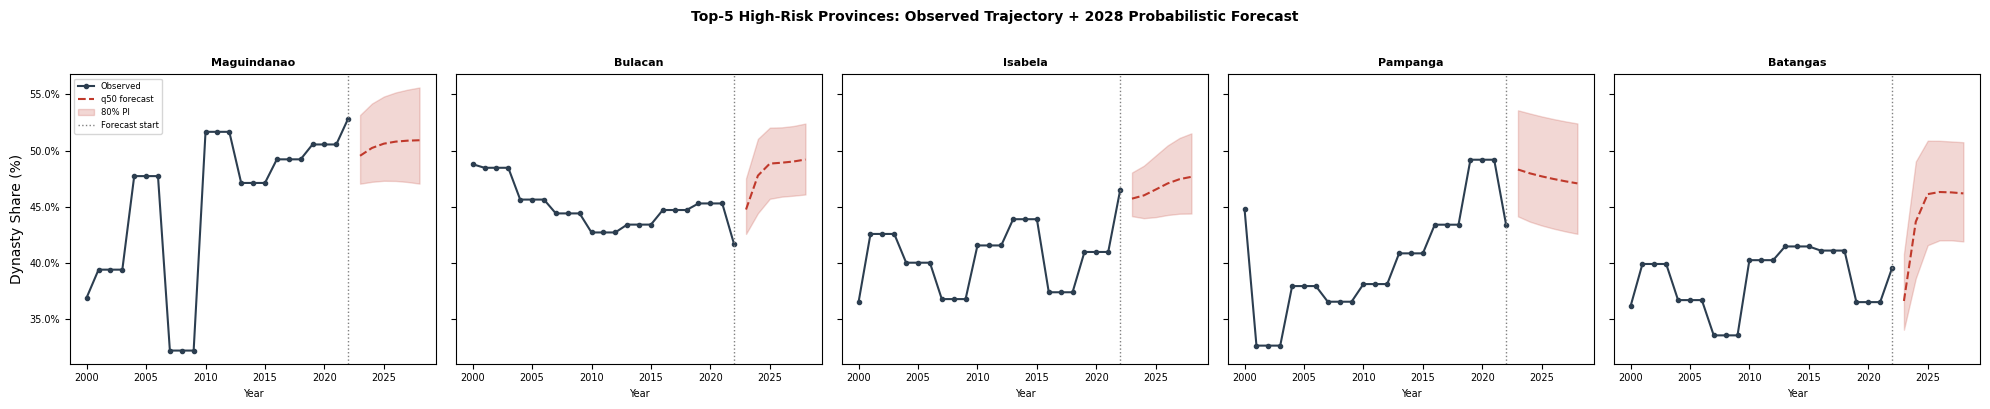

Figure saved → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_top5_trajectories_2028.png

Top-5 high-risk provinces (2031 q50):


,rank,prov_name,year,horizon,q10_dynasty_share,q50_dynasty_share,q90_dynasty_share,pi_width
0,1,Maguindanao,2031,2031,50.12%,53.16%,55.87%,5.75%
1,2,Pampanga,2031,2031,44.13%,48.91%,52.27%,8.14%
2,3,Isabela,2031,2031,45.22%,47.74%,50.06%,4.84%
3,4,Bulacan,2031,2031,43.17%,45.49%,47.69%,4.51%
4,5,Pangasinan,2031,2031,40.75%,44.02%,47.06%,6.31%


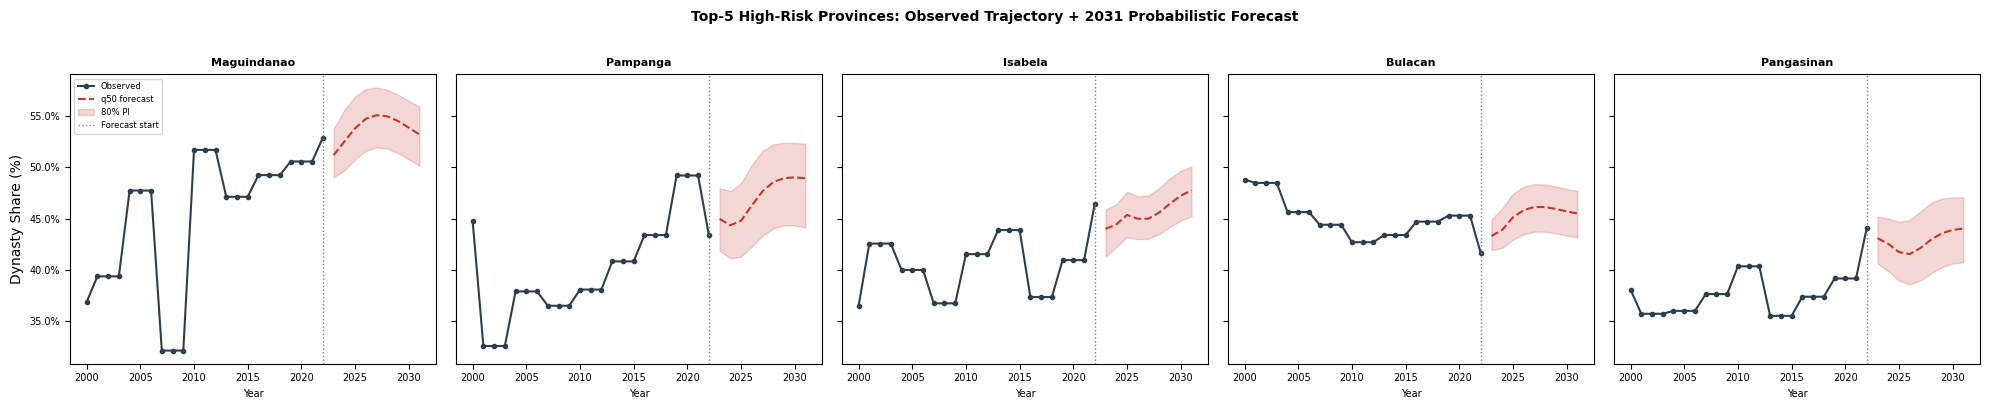

Figure saved → /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_top5_trajectories_2031.png

Top-5 summary CSV saved → /Users/renzo/Projects/Datubase-ph/outputs/results/top5_high_risk_provinces_2028_2031.csv
Figures generated:
  2028: /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_top5_trajectories_2028.png
  2031: /Users/renzo/Projects/Datubase-ph/outputs/figures/fig_top5_trajectories_2031.png


In [23]:
# ============================================================
# §3.4.8 — Top-5 High-Risk Province Trajectory Plots
# STANDALONE: loads from tft_forecast_output.csv and
# tft_master_dataset.csv. No model required.
#
# This cell now computes and visualizes the Top-5 high-risk
# provinces separately for the 2028 and 2031 forecast horizons.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
CWD         = Path().resolve()
ROOT        = CWD if (CWD / 'data' / 'final').exists() else CWD.parent
DATA_DIR    = ROOT / 'data' / 'final'
RESULTS_DIR = ROOT / 'outputs' / 'results'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load dependencies ─────────────────────────────────────────
fc_all  = pd.read_csv(RESULTS_DIR / 'tft_forecast_output.csv')
df_hist = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')
df_hist = df_hist[df_hist['year'] <= 2022].copy()

# Ensure numeric year/horizon fields
fc_all['year']    = fc_all['year'].astype(int)
fc_all['horizon'] = fc_all['horizon'].astype(int)

# ── Helper functions ──────────────────────────────────────────
def get_top5_by_forecast_year(forecast_year: int) -> pd.DataFrame:
    """
    Returns the terminal forecast row for the Top-5 provinces
    ranked by median predicted dynasty share (q50) for a given
    forecast year/horizon.
    """
    sub = (
        fc_all[(fc_all['horizon'] == forecast_year) & (fc_all['year'] == forecast_year)]
        .copy()
        .sort_values('q50_dynasty_share', ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError(
            f'No forecast rows found for horizon={forecast_year} and year={forecast_year}. '
            'Check tft_forecast_output.csv.'
        )

    sub.insert(0, 'rank', np.arange(1, len(sub) + 1))
    sub['pi_width'] = sub['q90_dynasty_share'] - sub['q10_dynasty_share']

    return sub[
        [
            'rank',
            'prov_name',
            'year',
            'horizon',
            'q10_dynasty_share',
            'q50_dynasty_share',
            'q90_dynasty_share',
            'pi_width'
        ]
    ]


def plot_top5_trajectories(forecast_year: int, top5_df: pd.DataFrame) -> Path:
    """
    Plots observed dynasty-share trajectories from 2000–2022 and
    the probabilistic forecast trajectory up to the selected
    forecast year.
    """
    top5 = top5_df['prov_name'].tolist()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

    for ax, prov in zip(axes, top5):
        hist = df_hist[df_hist['prov_name'] == prov].sort_values('year')
        fc_p = (
            fc_all[(fc_all['prov_name'] == prov) & (fc_all['horizon'] == forecast_year)]
            .sort_values('year')
        )

        ax.plot(
            hist['year'],
            hist['dynasty_share'],
            'o-',
            color='#2c3e50',
            lw=1.5,
            ms=3,
            label='Observed'
        )
        ax.plot(
            fc_p['year'],
            fc_p['q50_dynasty_share'],
            '--',
            color='#c0392b',
            lw=1.5,
            label='q50 forecast'
        )
        ax.fill_between(
            fc_p['year'],
            fc_p['q10_dynasty_share'],
            fc_p['q90_dynasty_share'],
            alpha=0.2,
            color='#c0392b',
            label='80% PI'
        )

        ax.axvline(2022, color='gray', linestyle=':', lw=1, label='Forecast start')
        ax.set_title(prov, fontsize=8, fontweight='bold')
        ax.set_xlabel('Year', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    axes[0].set_ylabel('Dynasty Share (%)')
    axes[0].legend(fontsize=6, loc='upper left')

    fig.suptitle(
        f'Top-5 High-Risk Provinces: Observed Trajectory + {forecast_year} Probabilistic Forecast',
        fontsize=10,
        fontweight='bold',
        y=1.01
    )
    plt.tight_layout()

    out_path = FIGURES_DIR / f'fig_top5_trajectories_{forecast_year}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()

    print(f'Figure saved → {out_path}')
    return out_path


# ── Compute + visualize Top-5 provinces for each forecast year ─
top5_tables = {}
figure_paths = {}

for forecast_year in [2028, 2031]:
    top5_tables[forecast_year] = get_top5_by_forecast_year(forecast_year)

    print(f'\nTop-5 high-risk provinces ({forecast_year} q50):')
    display(
        top5_tables[forecast_year].style.format(
            {
                'q10_dynasty_share': '{:.2f}%',
                'q50_dynasty_share': '{:.2f}%',
                'q90_dynasty_share': '{:.2f}%',
                'pi_width': '{:.2f}%'
            }
        )
    )

    figure_paths[forecast_year] = plot_top5_trajectories(
        forecast_year,
        top5_tables[forecast_year]
    )

# ── Optional export of Top-5 summary tables ───────────────────
top5_summary = pd.concat(
    top5_tables.values(),
    keys=top5_tables.keys(),
    names=['forecast_year', 'row']
).reset_index(level='forecast_year').reset_index(drop=True)

top5_summary.to_csv(RESULTS_DIR / 'top5_high_risk_provinces_2028_2031.csv', index=False)

print('\nTop-5 summary CSV saved →', RESULTS_DIR / 'top5_high_risk_provinces_2028_2031.csv')
print('Figures generated:')
for year, path in figure_paths.items():
    print(f'  {year}: {path}')

---
## 13 · Output Summary

In [24]:
# ============================================================
# Cell 13 — Master Export + Output Manifest
# STANDALONE: re-derives all exportable data from CSVs and
# saves corrected versions. Run this after cells 10B, 11, 12
# have been run at least once to confirm figures look correct.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────
CWD         = Path().resolve()
ROOT        = CWD if (CWD / 'data' / 'final').exists() else CWD.parent
DATA_DIR    = ROOT / 'data' / 'final'
OUT_DIR     = ROOT / 'outputs'
MODEL_DIR   = OUT_DIR / 'models'
RESULTS_DIR = OUT_DIR / 'results'
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# 1. ATTENTION WEIGHTS — preserve model-extracted years only
# ══════════════════════════════════════════════════════════════
attn_df = pd.read_csv(RESULTS_DIR / 'tft_attention_weights.csv')
attn_cols = [c for c in attn_df.columns if c.startswith('attention_weight_')]
HIST_YEARS = [int(c.split('_')[-1]) for c in attn_cols]

if not attn_cols:
    raise ValueError('No attention_weight_* columns found. Run the attention export cell first.')

attn_df = attn_df.sort_values('prov_name').reset_index(drop=True)
attn_wide = attn_df.set_index('prov_name')[attn_cols].copy()

# Row-normalize only. Do NOT impute 2000 or any missing year.
row_sums = attn_wide.sum(axis=1).replace(0, 1)
attn_norm = attn_wide.div(row_sums, axis=0)

attn_export = attn_norm.copy()
attn_export.insert(0, 'prov_name', attn_export.index)
attn_export['forecast_horizon_year'] = 2028
attn_export['encoder_year_start'] = min(HIST_YEARS)
attn_export['encoder_year_end'] = max(HIST_YEARS)
attn_export['encoder_length_actual'] = len(HIST_YEARS)
attn_export.to_csv(RESULTS_DIR / 'tft_attention_weights.csv', index=False)
print(f'✓ tft_attention_weights.csv exported without year imputation ({min(HIST_YEARS)}–{max(HIST_YEARS)})')

coverage_summary = pd.DataFrame({
    'forecast_horizon_year': [2028],
    'configured_encoder_length': [ENCODER_LENGTH if 'ENCODER_LENGTH' in globals() else len(HIST_YEARS)],
    'actual_encoder_year_start': [min(HIST_YEARS)],
    'actual_encoder_year_end': [max(HIST_YEARS)],
    'actual_encoder_years': [', '.join(map(str, HIST_YEARS))],
    'note': ['Attention heatmap includes only model-extracted encoder years; no fabricated 2000 value.'],
})
coverage_summary.to_csv(RESULTS_DIR / 'tft_attention_year_coverage_summary.csv', index=False)

# Export heatmap figure
vmax = np.percentile(attn_norm.values.flatten(), 85)
fig, ax = plt.subplots(figsize=(12, max(8, len(attn_df) * 0.22)))
sns.heatmap(
    attn_norm.values,
    ax          = ax,
    xticklabels = [str(y) for y in HIST_YEARS],
    yticklabels = attn_df['prov_name'].tolist(),
    cmap        = 'YlOrRd',
    vmin        = 0,
    vmax        = vmax,
    linewidths  = 0.15,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Row-Normalized Mean Attention Weight (85th pct cap)'},
)
ax.set_title(
    f'Temporal Attention Profiles — Actual Encoder Window Used for 2028 Forecast ({min(HIST_YEARS)}–{max(HIST_YEARS)})',
    fontweight='bold', fontsize=10,
)
ax.set_xlabel('Encoder Year')
ax.set_ylabel('Province')
if 2022 in HIST_YEARS:
    ax.axvline(HIST_YEARS.index(2022) + 0.5, color='steelblue', lw=1.5,
               linestyle='--', label='Mandanas-Garcia / Last Observed Year (2022)')
    ax.legend(fontsize=8, loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=6.5)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()
print(f'✓ fig_attention_heatmap.png exported')

# ══════════════════════════════════════════════════════════════
# 2. DASHBOARD FORECAST — risk tiers + export
# ══════════════════════════════════════════════════════════════
fc_all  = pd.read_csv(RESULTS_DIR / 'tft_forecast_output.csv')
df_hist = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')
df_hist = df_hist[df_hist['year'] <= 2022].copy()
fc_all['horizon'] = fc_all['horizon'].astype(int)

def assign_risk_tier(q50: float) -> str:
    if q50 < 33:   return 'Low Risk'
    elif q50 < 50: return 'Moderate Risk'
    elif q50 < 70: return 'High Risk'
    else:          return 'Critical Capture Risk'

baseline_2022 = (
    df_hist[df_hist['year'] == 2022]
    .set_index('prov_name')['dynasty_share']
    .rename('dynasty_share_2022')
)
dash_df = fc_all.copy()
dash_df['risk_tier']       = dash_df['q50_dynasty_share'].apply(assign_risk_tier)
dash_df['pi_width']        = dash_df['q90_dynasty_share'] - dash_df['q10_dynasty_share']
dash_df                    = dash_df.join(baseline_2022, on='prov_name')
dash_df['delta_from_2022'] = dash_df['q50_dynasty_share'] - dash_df['dynasty_share_2022']
dash_df['trajectory']      = dash_df['delta_from_2022'].apply(
    lambda d: 'Increasing' if d > 2 else ('Decreasing' if d < -2 else 'Stable')
)
dash_df.to_csv(RESULTS_DIR / 'dashboard_forecast_final.csv', index=False)
print(f'✓ dashboard_forecast_final.csv exported')

for yr_val in [2028, 2031]:
    sub = dash_df[(dash_df['horizon'] == yr_val) & (dash_df['year'] == yr_val)]
    if sub.empty: continue
    print(f'\n── {yr_val} Risk Distribution ({len(sub)} provinces) ──')
    print(sub['risk_tier'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
# 3. TOP-5 TRAJECTORY FIGURE — export
# ══════════════════════════════════════════════════════════════
top5 = (
    fc_all[(fc_all['horizon'] == 2028) & (fc_all['year'] == 2028)]
    .nlargest(5, 'q50_dynasty_share')['prov_name']
    .tolist()
)
print(f'\nTop-5 high-risk provinces (2028): {top5}')

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, prov in zip(axes, top5):
    hist = df_hist[df_hist['prov_name'] == prov].sort_values('year')
    fc_p = fc_all[(fc_all['prov_name'] == prov) & (fc_all['horizon'] == 2028)].sort_values('year')
    ax.plot(hist['year'], hist['dynasty_share'],
            'o-', color='#2c3e50', lw=1.5, ms=3, label='Observed')
    ax.plot(fc_p['year'], fc_p['q50_dynasty_share'],
            '--', color='#c0392b', lw=1.5, label='q50 forecast')
    ax.fill_between(fc_p['year'], fc_p['q10_dynasty_share'], fc_p['q90_dynasty_share'],
                    alpha=0.2, color='#c0392b', label='80% PI')
    ax.axvline(2022, color='gray', linestyle=':', lw=1, label='Mandanas-Garcia')
    ax.set_title(prov, fontsize=8, fontweight='bold')
    ax.set_xlabel('Year', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylabel('Dynasty Share (%)')
axes[0].legend(fontsize=6, loc='upper left')
fig.suptitle(
    'Top-5 High-Risk Provinces: Observed Trajectory + 2028 Probabilistic Forecast',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_top5_trajectories.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'✓ fig_top5_trajectories.png exported')

# ══════════════════════════════════════════════════════════════
# 4. OUTPUT MANIFEST
# ══════════════════════════════════════════════════════════════
print('\n' + '=' * 65)
print('  MODELING COMPLETE — Output Manifest')
print('=' * 65)
manifest = [
    (RESULTS_DIR / 'optuna_trials.csv',                                  'Optuna hyperparameter search log'),
    (RESULTS_DIR / 'ground_truth_alignment_test_split_2019_2022.csv',    'Actual vs predicted 2019–2022 held-out alignment'),
    (RESULTS_DIR / 'ground_truth_alignment_2022_high_mid_low.csv',       '2022 highest / middle / lowest actual DSS comparison'),
    (RESULTS_DIR / 'benchmark_results.csv',                              'Naive / SARIMA / Ridge / TFT MAE + MASE'),
    (RESULTS_DIR / 'section8_actual_quantile_losses.csv',                'Per-province-year quantile losses'),
    (RESULTS_DIR / 'section8_quantile_loss_summary.csv',                 'MQL and 80% PI coverage summary'),
    (RESULTS_DIR / 'section8_quantile_metrics.csv',                      'Quantile metrics for figure/table use'),
    (RESULTS_DIR / 'tft_forecast_output.csv',                            'q10/q50/q90 forecasts 2023–2031'),
    (RESULTS_DIR / 'dashboard_forecast_final.csv',                       'Full dashboard export with risk tiers'),
    (RESULTS_DIR / 'section8_forecast_uncertainty_distribution.csv',      'Forecast interval-width distribution'),
    (RESULTS_DIR / 'tft_variable_importance.csv',                        'VSN global feature importance scores'),
    (RESULTS_DIR / 'tft_attention_weights.csv',                          'Temporal attention weight profiles'),
    (MODEL_DIR   / 'tft_eval_best_heldout.ckpt',                         'Held-out evaluation TFT checkpoint'),
    (MODEL_DIR   / 'tft_final_best.ckpt',                                'Final full-history TFT checkpoint for 2028'),
    (MODEL_DIR   / 'tft_2031_best.ckpt',                                 'Final full-history TFT checkpoint for 2031'),
    (FIGURES_DIR / 'fig_ground_truth_alignment_scatter_2019_2022.png',   'Actual vs predicted held-out scatter plot'),
    (FIGURES_DIR / 'fig_ground_truth_alignment_2022_high_mid_low.png',    '2022 high / mid / low ground-truth alignment chart'),
    (FIGURES_DIR / 'fig_benchmark.png',                                  'Benchmark bar chart'),
    (FIGURES_DIR / 'fig_section8_quantile_metrics.png',                  'Quantile loss bar chart'),
    (FIGURES_DIR / 'fig_forecast_uncertainty_distribution.png',          'Forecast uncertainty histogram'),
    (FIGURES_DIR / 'fig_variable_importance.png',                        'VSN feature importance bar chart'),
    (FIGURES_DIR / 'fig_attention_heatmap.png',                          'Province × time attention heatmap'),
    (FIGURES_DIR / 'fig_top5_trajectories.png',                          'Top-5 province trajectory plots'),
]
for path, desc in manifest:
    exists = '✓' if path.exists() else '✗'
    print(f'  {exists}  {path.name:<42}  {desc}')
print('=' * 65)


✓ tft_attention_weights.csv exported without year imputation (2014–2022)
✓ fig_attention_heatmap.png exported
✓ dashboard_forecast_final.csv exported

── 2028 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         54
Moderate Risk    26
High Risk         1

── 2031 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         58
Moderate Risk    22
High Risk         1

Top-5 high-risk provinces (2028): ['Maguindanao', 'Bulacan', 'Isabela', 'Pampanga', 'Batangas']
✓ fig_top5_trajectories.png exported

  MODELING COMPLETE — Output Manifest
  ✓  optuna_trials.csv                           Optuna hyperparameter search log
  ✓  ground_truth_alignment_test_split_2019_2022.csv  Actual vs predicted 2019–2022 held-out alignment
  ✓  ground_truth_alignment_2022_high_mid_low.csv  2022 highest / middle / lowest actual DSS comparison
  ✓  benchmark_results.csv                       Naive / SARIMA / Ridge / TFT MAE + MASE
  ✓  section8_actual_quantile_losses.csv         Per-province-year qu